# 🎯 Eventzella — Analyse Complète des Données
### Pipeline : Chargement → Nettoyage → EDA → Feature Selection → Visualisation
---

## 📦 0. Installation des librairies

In [4]:
!pip install openpyxl missingno -q
!pip install xgboost lightgbm catboost prophet -q

## 📂 1. Importation des librairies & Chargement des données

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler
#from google.colab import files
#import warnings
#warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print('✅ Librairies importées avec succès')

✅ Librairies importées avec succès


In [6]:
# ── Chargement du fichier Excel depuis le projet ─────────────────────────────
from pathlib import Path

# Détection du dossier racine du projet (EventZella)
cwd = Path.cwd()
candidates = [cwd, *cwd.parents]
excel_path = None
for base in candidates:
    candidate = base / "data" / "eventzella_schema.xlsx"
    if candidate.exists():
        excel_path = candidate
        break

if excel_path is None:
    raise FileNotFoundError("eventzella_schema.xlsx introuvable. Vérifie le dossier data/ du projet EventZella.")

print(f"📄 Fichier Excel utilisé : {excel_path}")
sheets = pd.read_excel(excel_path, sheet_name=None)

# Chargement de chaque feuille dans une variable dédiée
beneficiary      = sheets["BENEFICIARY"]
provider         = sheets["PROVIDER"]
category         = sheets["CATEGORY"]
subcategory      = sheets["SUBCATEGORY"]
service          = sheets["SERVICE"]
event            = sheets["EVENT"]
reservation      = sheets["RESERVATION"]
evaluation       = sheets["EVALUATION"]
complaint        = sheets["COMPLAINT"]
visitors         = sheets["VISITORS"]
marketing        = sheets["MARKETING_SPEND"]

print("✅ Toutes les feuilles chargées !")
for name, df in sheets.items():
    print(f"  📄 {name:20s} → {df.shape[0]:6d} lignes × {df.shape[1]} colonnes")

📄 Fichier Excel utilisé : c:\Users\chari\.gemini\antigravity\scratch\EventZella\data\eventzella_schema.xlsx
✅ Toutes les feuilles chargées !
  📄 BENEFICIARY          →   5000 lignes × 5 colonnes
  📄 PROVIDER             →    800 lignes × 6 colonnes
  📄 CATEGORY             →      4 lignes × 2 colonnes
  📄 SUBCATEGORY          →      4 lignes × 3 colonnes
  📄 SERVICE              →   2500 lignes × 6 colonnes
  📄 EVENT                →  12000 lignes × 6 colonnes
  📄 RESERVATION          →  18000 lignes × 6 colonnes
  📄 EVALUATION           →  12000 lignes × 4 colonnes
  📄 COMPLAINT            →   2500 lignes × 6 colonnes
  📄 VISITORS             →    365 lignes × 4 colonnes
  📄 MARKETING_SPEND      →     36 lignes × 4 colonnes


## 🔍 2. Aperçu général des données (Data Overview)

In [7]:
# ── Aperçu de chaque table ───────────────────────────────────────────────────
for name, df in sheets.items():
    print(f'\n{'='*60}')
    print(f'📋 TABLE : {name}')
    print(f'{'='*60}')
    display(df.head(3))
    print('\nTypes de données :')
    print(df.dtypes)


📋 TABLE : BENEFICIARY


,id_beneficiary,first_name,last_name,email,phone
0,1,Derek,Lara,NaN,21620426159
1,2,Lori,Wu,heatherlopez@example.com,21658030013
2,3,Holly,Haas,xsanders@example.net,21675668113



Types de données :
id_beneficiary     int64
first_name        object
last_name         object
email             object
phone              int64
dtype: object

📋 TABLE : PROVIDER


,id_provider,name,service_type,email,phone,city
0,1,Cooper-Lloyd,Decoration,williamsrobert@sutton.org,21675694650,Jendouba
1,2,"Andrews, Hart and Smith",Decoration,zturner@watson.info,21676863739,Kébili
2,3,Gutierrez LLC,Decoration,ashley04@haney.com,21642179254,Kairouan



Types de données :
id_provider      int64
name            object
service_type    object
email           object
phone            int64
city            object
dtype: object

📋 TABLE : CATEGORY


...


Types de données :
id_complaint       int64
description       object
status            object
id_beneficiary     int64
id_provider        int64
subject           object
dtype: object

📋 TABLE : VISITORS


,id,date,visitors,reservations
0,93,03/01/2022 17:30:26,3538,185
1,187,06/01/2022 06:52:24,595,147
2,86,11/01/2022 23:55:58,4016,130



Types de données :
id               int64
date            object
visitors         int64
reservations     int64
dtype: object

📋 TABLE : MARKETING_SPEND


,id,month,marketing_spend,new_beneficiaries
0,1,2023-01-01 00:00:00,29217,1568
1,2,2023-02-01 00:00:00,142420,1166
2,3,2023-03-01 00:00:00,24307,1488



Types de données :
id                    int64
month                object
marketing_spend       int64
new_beneficiaries     int64
dtype: object


In [8]:
# ── Statistiques descriptives des colonnes numériques ───────────────────────
for name, df in sheets.items():
    num_cols = df.select_dtypes(include='number').columns.tolist()
    if num_cols:
        print(f'\n📊 {name} — Statistiques numériques :')
        display(df[num_cols].describe().round(2))


📊 BENEFICIARY — Statistiques numériques :


,id_beneficiary,phone
count,5000.00,5.000000e+03
mean,2500.50,2.165529e+10
std,1443.52,2.429937e+07
min,1.00,2.162003e+10
25%,1250.75,2.163488e+10
50%,2500.50,2.164972e+10
75%,3750.25,2.167569e+10
max,5000.00,2.169999e+10



📊 PROVIDER — Statistiques numériques :


,id_provider,phone
count,800.00,8.000000e+02
mean,400.50,2.165603e+10
std,231.08,2.407824e+07
min,1.00,2.162002e+10
25%,200.75,2.163586e+10
50%,400.50,2.165111e+10
75%,600.25,2.167551e+10
max,800.00,2.169990e+10



📊 CATEGORY — Statistiques numériques :


...

,id_complaint,id_beneficiary,id_provider
count,2500.00,2500.00,2500.00
mean,1250.50,2496.55,406.11
std,721.83,1435.69,233.54
min,1.00,1.00,1.00
25%,625.75,1279.75,199.75
50%,1250.50,2466.50,411.00
75%,1875.25,3741.75,614.25
max,2500.00,4999.00,800.00



📊 VISITORS — Statistiques numériques :


,id,visitors,reservations
count,365.00,365.00,365.00
mean,183.00,2784.07,143.99
std,105.51,2641.68,83.19
min,1.00,58.00,0.00
25%,92.00,1141.00,70.00
50%,183.00,2505.00,143.00
75%,274.00,3679.00,208.00
max,365.00,22215.00,300.00



📊 MARKETING_SPEND — Statistiques numériques :


,id,marketing_spend,new_beneficiaries
count,36.00,36.00,36.00
mean,18.50,20977.67,1131.83
std,10.54,23632.22,573.65
min,1.00,2669.00,75.00
25%,9.75,10508.75,802.75
50%,18.50,15930.00,1248.00
75%,27.25,24619.75,1547.00
max,36.00,142420.00,1982.00


## 🧹 3. Nettoyage des données (Data Cleaning)
### 3.1 — Valeurs manquantes (Missing Values)

In [9]:
# ── Résumé global des valeurs manquantes ────────────────────────────────────
print('🔎 VALEURS MANQUANTES PAR TABLE\n')
for name, df in sheets.items():
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    summary = pd.DataFrame({'Manquants': missing, '% Manquant': missing_pct})
    summary = summary[summary['Manquants'] > 0]
    if not summary.empty:
        print(f'\n📄 {name}')
        display(summary)

🔎 VALEURS MANQUANTES PAR TABLE


📄 BENEFICIARY


,Manquants,% Manquant
last_name,348,6.96
email,400,8.00



📄 PROVIDER


,Manquants,% Manquant
email,67,8.38



📄 SERVICE


,Manquants,% Manquant
price,214,8.56
title,349,13.96



📄 EVALUATION


,Manquants,% Manquant
comment,312,2.6


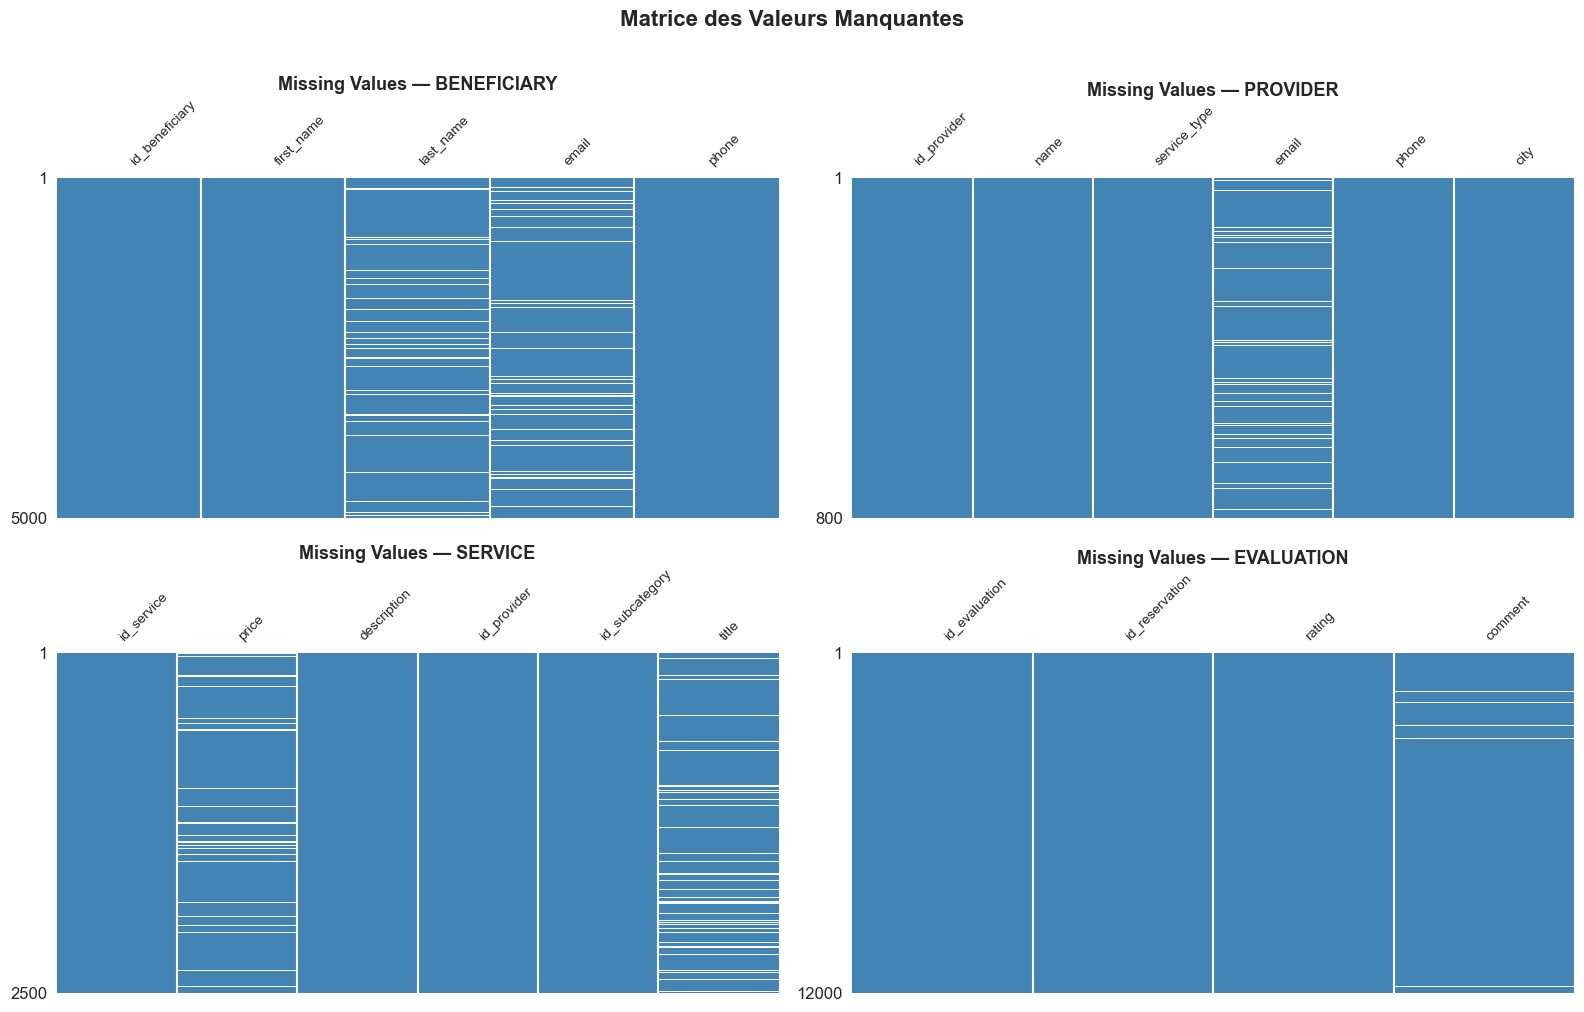

In [10]:
# ── Visualisation matrice des valeurs manquantes ─────────────────────────────
tables_with_missing = ['BENEFICIARY', 'PROVIDER', 'SERVICE', 'EVALUATION']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, name in enumerate(tables_with_missing):
    msno.matrix(sheets[name], ax=axes[i], sparkline=False, fontsize=10, color=(0.27, 0.52, 0.71))
    axes[i].set_title(f'Missing Values — {name}', fontsize=13, fontweight='bold')

plt.suptitle('Matrice des Valeurs Manquantes', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('missing_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

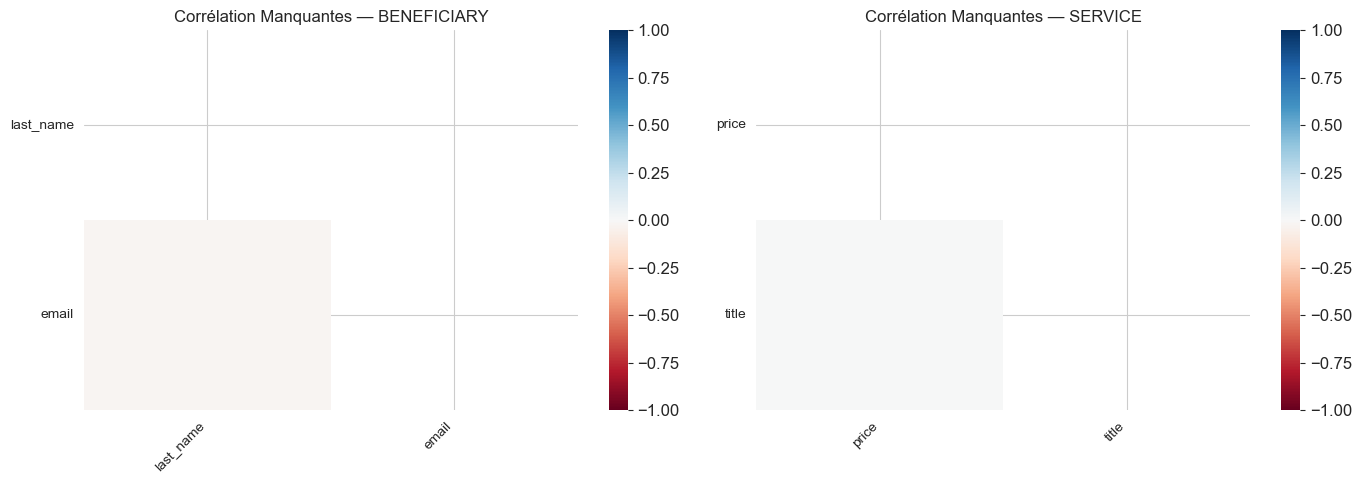

In [11]:
# ── Heatmap des valeurs manquantes ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, ['BENEFICIARY', 'SERVICE']):
    msno.heatmap(sheets[name], ax=ax, fontsize=10)
    ax.set_title(f'Corrélation Manquantes — {name}', fontsize=12)
plt.tight_layout()
plt.show()

### 3.2 — Traitement des valeurs manquantes

In [12]:
# ── Copies de travail
ben   = beneficiary.copy()
prov  = provider.copy()
svc   = service.copy()
evl   = evaluation.copy()

# BENEFICIARY : last_name (6.96%) → 'Unknown' | email (8%) → 'no_email@unknown.com'
ben['last_name'].fillna('Unknown', inplace=True)
ben['email'].fillna('no_email@unknown.com', inplace=True)

# PROVIDER : email (8.375%) → 'no_email@provider.com'
prov['email'].fillna('no_email@provider.com', inplace=True)

# SERVICE : price (8.56%) → médiane par subcategory | title (13.96%) → 'No Title'
svc['price'] = svc.groupby('id_subcategory')['price'].transform(
    lambda x: x.fillna(x.median())
)
svc['price'].fillna(svc['price'].median(), inplace=True)  # Fallback global
svc['title'].fillna('No Title', inplace=True)

# EVALUATION : comment (2.6%) → 'No Comment'
evl['comment'].fillna('No Comment', inplace=True)

# Vérification
print('✅ Vérification après traitement :')
for name, df in [('BENEFICIARY', ben), ('PROVIDER', prov), ('SERVICE', svc), ('EVALUATION', evl)]:
    total_missing = df.isnull().sum().sum()
    print(f'  {name:15s} → {total_missing} valeurs manquantes restantes')

✅ Vérification après traitement :
  BENEFICIARY     → 0 valeurs manquantes restantes
  PROVIDER        → 0 valeurs manquantes restantes
  SERVICE         → 0 valeurs manquantes restantes
  EVALUATION      → 0 valeurs manquantes restantes


### 3.3 — Valeurs aberrantes / Outliers

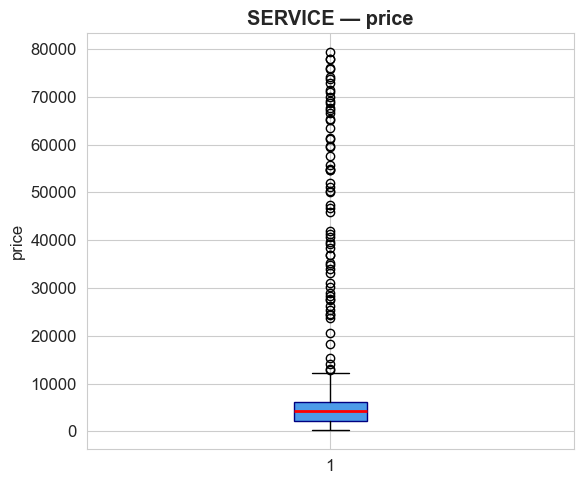

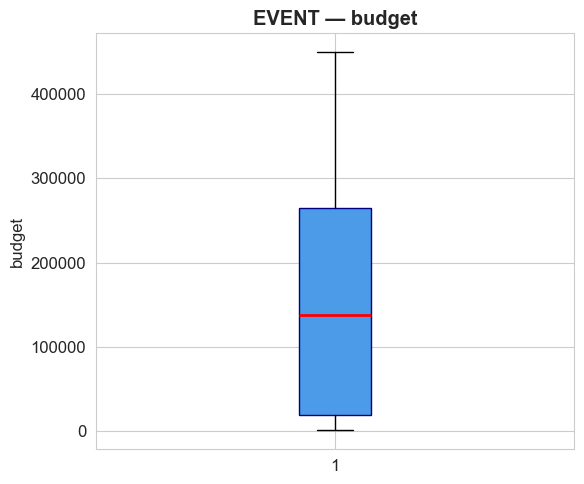

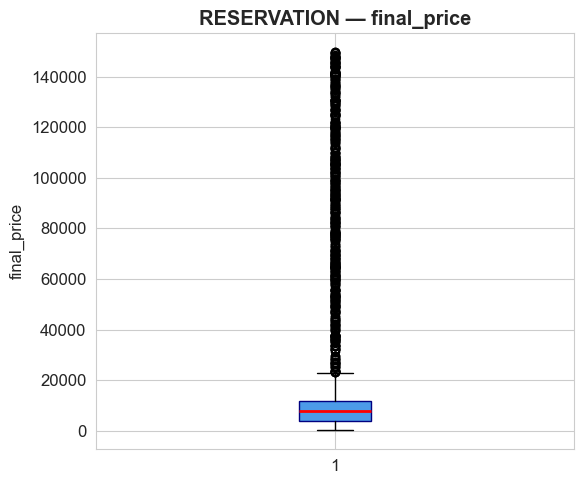

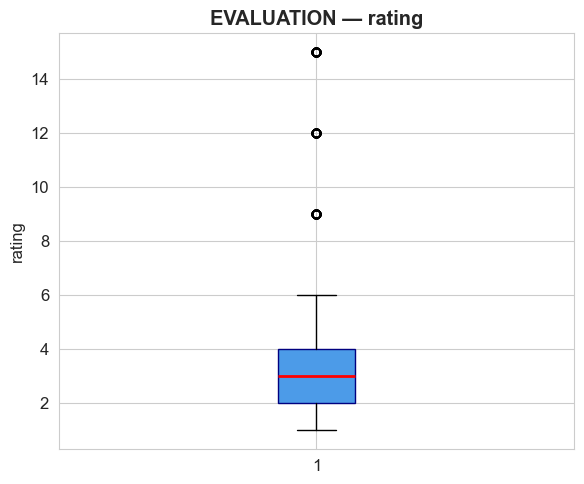

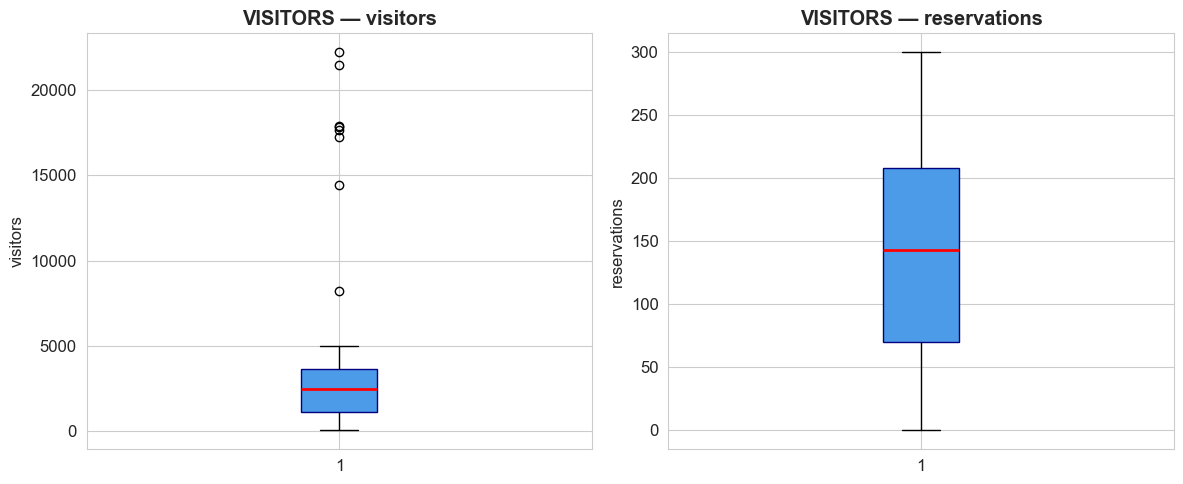

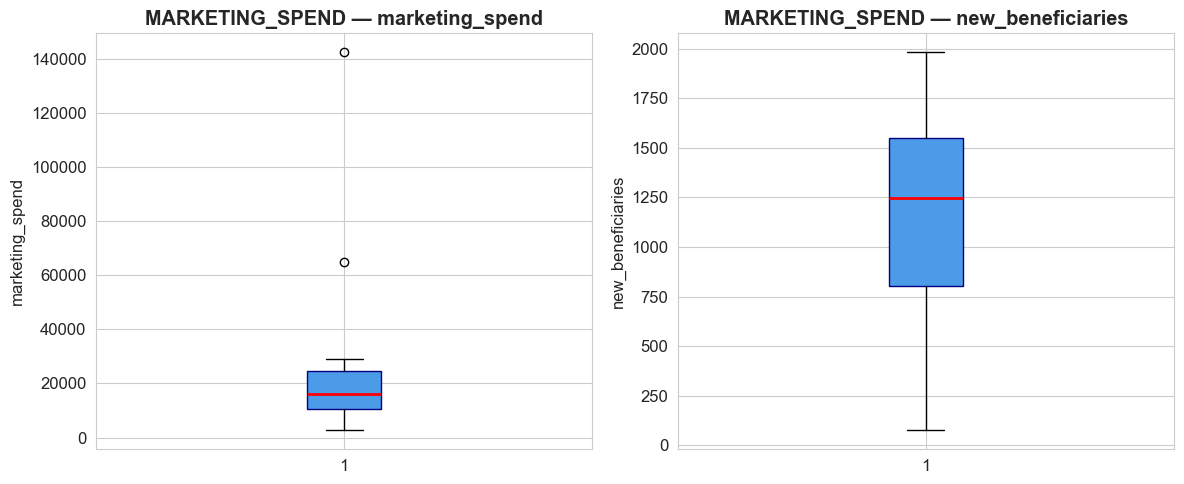

In [13]:
# ── Boxplots pour détecter les outliers ─────────────────────────────────────
outlier_cols = {
    'SERVICE'    : ['price'],
    'EVENT'      : ['budget'],
    'RESERVATION': ['final_price'],
    'EVALUATION' : ['rating'],
    'VISITORS'   : ['visitors', 'reservations'],
    'MARKETING_SPEND': ['marketing_spend', 'new_beneficiaries']
}

for table_name, cols in outlier_cols.items():
    df_temp = sheets[table_name]
    fig, axes = plt.subplots(1, len(cols), figsize=(6*len(cols), 5))
    if len(cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        ax.boxplot(df_temp[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#4C9BE8', color='navy'),
                   medianprops=dict(color='red', linewidth=2))
        ax.set_title(f'{table_name} — {col}', fontweight='bold')
        ax.set_ylabel(col)
    plt.tight_layout()
    plt.savefig(f'boxplot_{table_name}.png', bbox_inches='tight', dpi=150)
    plt.show()

In [14]:
# ── Détection des outliers par méthode IQR
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers, lower, upper

print('📊 RÉSUMÉ DES OUTLIERS (méthode IQR)\n')
for table_name, cols in outlier_cols.items():
    df_temp = sheets[table_name]
    for col in cols:
        outliers, low, up = detect_outliers_iqr(df_temp.dropna(subset=[col]), col)
        pct = len(outliers) / len(df_temp) * 100
        print(f'  {table_name}.{col:20s} → {len(outliers):5d} outliers ({pct:.1f}%)  |  Seuils: [{low:.0f}, {up:.0f}]')

📊 RÉSUMÉ DES OUTLIERS (méthode IQR)

  SERVICE.price                →    64 outliers (2.6%)  |  Seuils: [-3962, 12277]
  EVENT.budget               →     0 outliers (0.0%)  |  Seuils: [-350124, 633657]
  RESERVATION.final_price          →   495 outliers (2.8%)  |  Seuils: [-7521, 23121]
  EVALUATION.rating               →   228 outliers (1.9%)  |  Seuils: [-1, 7]
  VISITORS.visitors             →     8 outliers (2.2%)  |  Seuils: [-2666, 7486]
  VISITORS.reservations         →     0 outliers (0.0%)  |  Seuils: [-137, 415]
  MARKETING_SPEND.marketing_spend      →     2 outliers (5.6%)  |  Seuils: [-10658, 45786]
  MARKETING_SPEND.new_beneficiaries    →     0 outliers (0.0%)  |  Seuils: [-314, 2663]


In [15]:
# ── Détection des outliers par Z-Score
print('📊 OUTLIERS PAR Z-SCORE (|z| > 3)\n')
for table_name, cols in outlier_cols.items():
    df_temp = sheets[table_name]
    for col in cols:
        data = df_temp[col].dropna()
        z_scores = np.abs(stats.zscore(data))
        n_outliers = (z_scores > 3).sum()
        pct = n_outliers / len(data) * 100
        print(f'  {table_name}.{col:20s} → {n_outliers:5d} outliers ({pct:.1f}%)')

📊 OUTLIERS PAR Z-SCORE (|z| > 3)

  SERVICE.price                →    49 outliers (2.1%)
  EVENT.budget               →     0 outliers (0.0%)
  RESERVATION.final_price          →   387 outliers (2.1%)
  EVALUATION.rating               →   228 outliers (1.9%)
  VISITORS.visitors             →     7 outliers (1.9%)
  VISITORS.reservations         →     0 outliers (0.0%)
  MARKETING_SPEND.marketing_spend      →     1 outliers (2.8%)
  MARKETING_SPEND.new_beneficiaries    →     0 outliers (0.0%)


In [16]:
# Traitement des outliers
# SERVICE.price : plafonner à 99e percentile (winsorisation)
svc_clean = svc.copy()
p99_price = svc_clean['price'].quantile(0.99)
svc_clean['price'] = svc_clean['price'].clip(upper=p99_price)
print(f'SERVICE price plafonné à : {p99_price:.0f} TND')

# EVALUATION.rating : rating max = 5 → supprimer les lignes > 5
evl_clean = evl.copy()
nb_invalid_rating = (evl_clean['rating'] > 5).sum()
evl_clean = evl_clean[evl_clean['rating'] <= 5]
print(f'EVALUATION : {nb_invalid_rating} ratings > 5 supprimés')

# RESERVATION.final_price : winsorisation à 99e percentile
res_clean = reservation.copy()
p99_res = res_clean['final_price'].quantile(0.99)
res_clean['final_price'] = res_clean['final_price'].clip(upper=p99_res)
print(f'RESERVATION final_price plafonné à : {p99_res:.0f} TND')

# VISITORS.visitors : winsorisation à 99e percentile
vis_clean = visitors.copy()
p99_vis = vis_clean['visitors'].quantile(0.99)
vis_clean['visitors'] = vis_clean['visitors'].clip(upper=p99_vis)
print(f'VISITORS visitors plafonné à : {p99_vis:.0f}')

# MARKETING_SPEND.marketing_spend : winsorisation
mkt_clean = marketing.copy()
p99_mkt = mkt_clean['marketing_spend'].quantile(0.99)
mkt_clean['marketing_spend'] = mkt_clean['marketing_spend'].clip(upper=p99_mkt)
print(f'MARKETING spend plafonné à : {p99_mkt:.0f} TND')

print('\n Traitement des outliers terminé !')

SERVICE price plafonné à : 54937 TND
EVALUATION : 312 ratings > 5 supprimés
RESERVATION final_price plafonné à : 104921 TND
VISITORS visitors plafonné à : 17727
MARKETING spend plafonné à : 115267 TND

 Traitement des outliers terminé !


### 3.4 — Correction des types & Doublons

In [17]:
#Conversion des dates
res_clean_dates = res_clean.copy()
vis_clean_dates = vis_clean.copy()
event_clean = event.copy()
event_clean['event_date']             = pd.to_datetime(event_clean['event_date'], errors='coerce')
res_clean_dates['reservation_date']   = pd.to_datetime(res_clean_dates['reservation_date'], errors='coerce')
vis_clean_dates['date']               = pd.to_datetime(vis_clean_dates['date'], errors='coerce')

# Extraction de features temporelles pour EVENT
event_clean['year']    = event_clean['event_date'].dt.year
event_clean['month']   = event_clean['event_date'].dt.month
event_clean['weekday'] = event_clean['event_date'].dt.day_name()
event_clean['quarter'] = event_clean['event_date'].dt.quarter

print('✅ Dates converties et features temporelles créées')
display(event_clean[['event_date', 'year', 'month', 'quarter', 'weekday']].head())

✅ Dates converties et features temporelles créées


,event_date,year,month,quarter,weekday
0,2022-04-01 00:12:37,2022.0,4.0,2.0,Friday
1,2022-04-01 00:22:33,2022.0,4.0,2.0,Friday
2,2022-04-01 00:36:12,2022.0,4.0,2.0,Friday
3,2022-04-01 00:43:37,2022.0,4.0,2.0,Friday
4,2022-04-01 00:55:02,2022.0,4.0,2.0,Friday


In [18]:
# ── Vérification des doublons ─────────────────────────────────────────────────
print('🔎 DOUBLONS PAR TABLE :')
for name, df in sheets.items():
    n_dup = df.duplicated().sum()
    status = '⚠️' if n_dup > 0 else '✅'
    print(f'  {status} {name:20s} → {n_dup} doublons')

🔎 DOUBLONS PAR TABLE :
  ✅ BENEFICIARY          → 0 doublons
  ✅ PROVIDER             → 0 doublons
  ✅ CATEGORY             → 0 doublons
  ✅ SUBCATEGORY          → 0 doublons
  ✅ SERVICE              → 0 doublons
  ✅ EVENT                → 0 doublons
  ✅ RESERVATION          → 0 doublons
  ✅ EVALUATION           → 0 doublons
  ✅ COMPLAINT            → 0 doublons
  ✅ VISITORS             → 0 doublons
  ✅ MARKETING_SPEND      → 0 doublons


## 📊 4. Analyse Exploratoire (EDA)
### 4.1 — Variables catégorielles

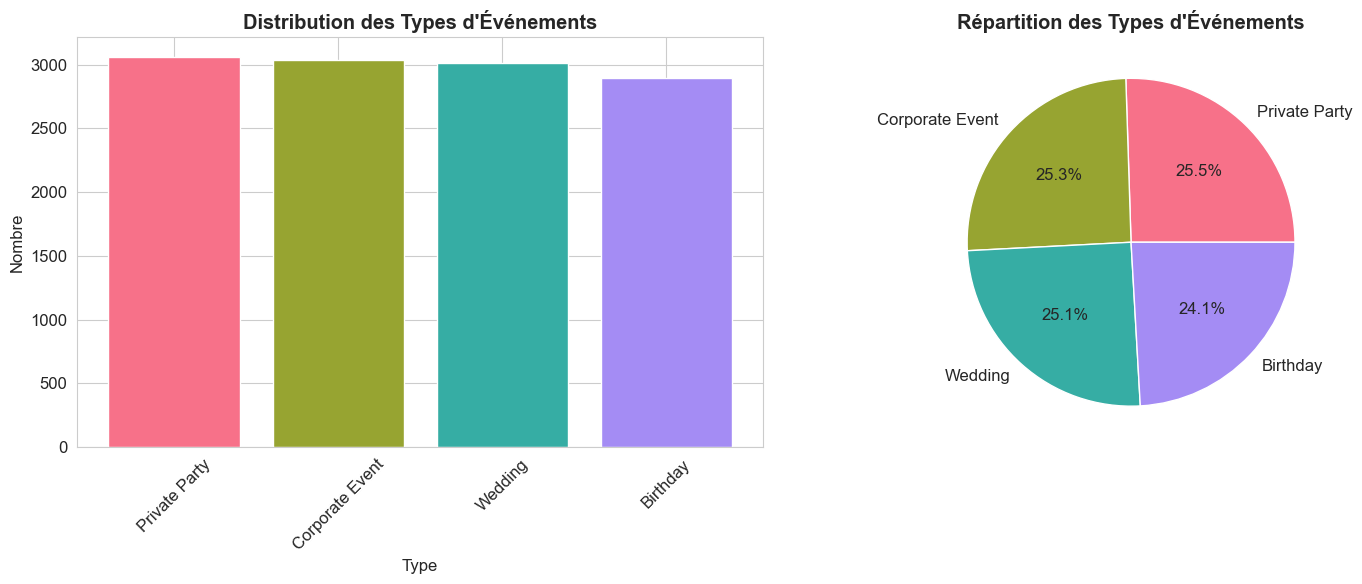

In [19]:
# ── Distribution des types d'événements ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

event_type_counts = event_clean['type'].value_counts()
axes[0].bar(event_type_counts.index, event_type_counts.values,
            color=sns.color_palette('husl', len(event_type_counts)))
axes[0].set_title('Distribution des Types d\'Événements', fontweight='bold')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Nombre')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(event_type_counts.values, labels=event_type_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('husl', len(event_type_counts)))
axes[1].set_title('Répartition des Types d\'Événements', fontweight='bold')

plt.tight_layout()
plt.savefig('event_types.png', bbox_inches='tight', dpi=150)
plt.show()

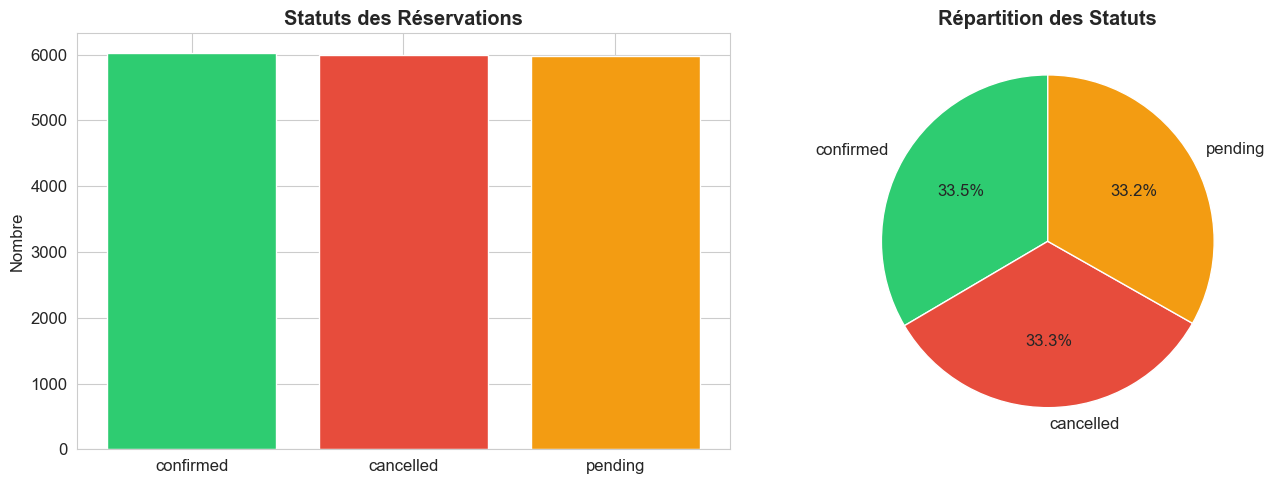

In [20]:
# ── Statuts des réservations ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

res_status = res_clean_dates['status'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f39c12']

axes[0].bar(res_status.index, res_status.values, color=colors)
axes[0].set_title('Statuts des Réservations', fontweight='bold')
axes[0].set_ylabel('Nombre')

axes[1].pie(res_status.values, labels=res_status.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Répartition des Statuts', fontweight='bold')

plt.tight_layout()
plt.savefig('reservation_status.png', bbox_inches='tight', dpi=150)
plt.show()

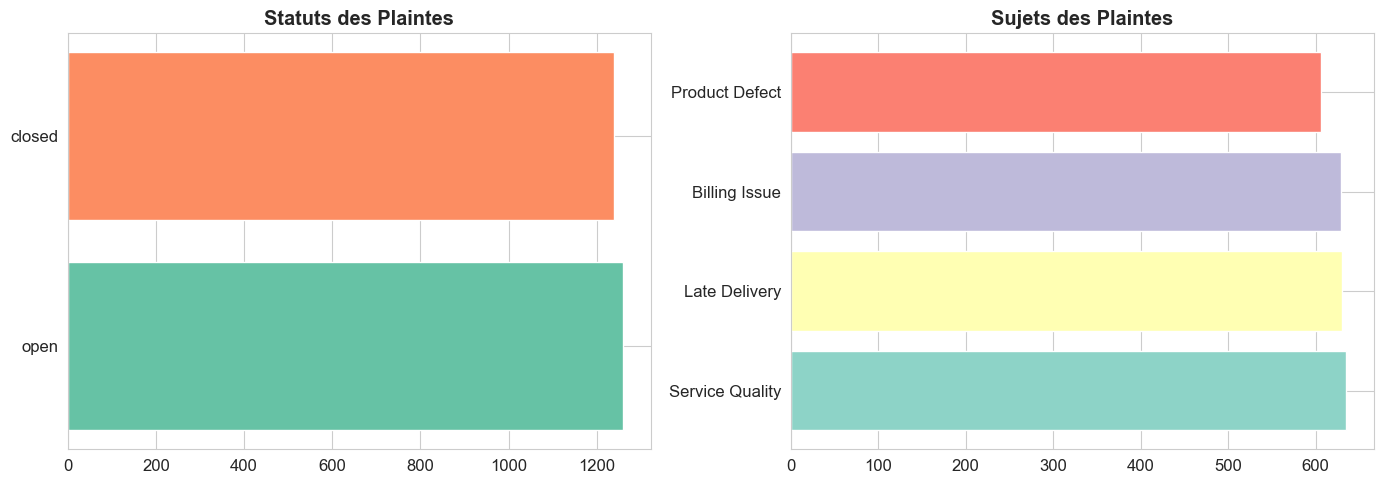

In [21]:
#Statuts des plaintes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comp_status = complaint['status'].value_counts()
comp_subject = complaint['subject'].value_counts()

axes[0].barh(comp_status.index, comp_status.values,
             color=sns.color_palette('Set2', len(comp_status)))
axes[0].set_title('Statuts des Plaintes', fontweight='bold')

axes[1].barh(comp_subject.index, comp_subject.values,
             color=sns.color_palette('Set3', len(comp_subject)))
axes[1].set_title('Sujets des Plaintes', fontweight='bold')

plt.tight_layout()
plt.savefig('complaints.png', bbox_inches='tight', dpi=150)
plt.show()

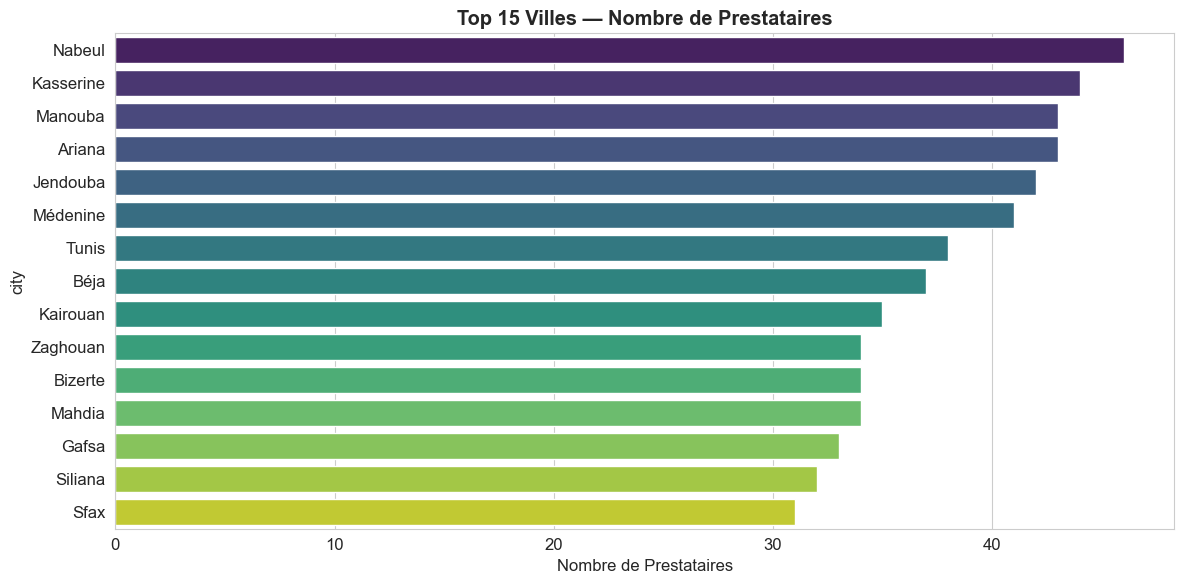

In [22]:
#Répartition des prestataires par ville
top_cities = provider['city'].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='viridis')
plt.title('Top 15 Villes — Nombre de Prestataires', fontweight='bold')
plt.xlabel('Nombre de Prestataires')
plt.tight_layout()
plt.savefig('provider_cities.png', bbox_inches='tight', dpi=150)
plt.show()

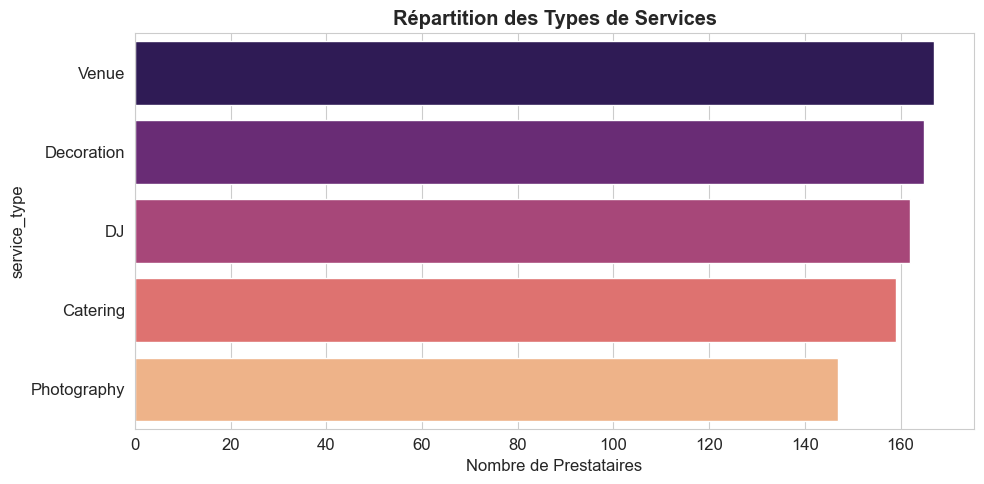

In [23]:
#Types de services des prestataires
service_types = provider['service_type'].value_counts()
plt.figure(figsize=(10, 5))
sns.barplot(x=service_types.values, y=service_types.index, palette='magma')
plt.title('Répartition des Types de Services', fontweight='bold')
plt.xlabel('Nombre de Prestataires')
plt.tight_layout()
plt.savefig('service_types.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.2 — Variables numériques

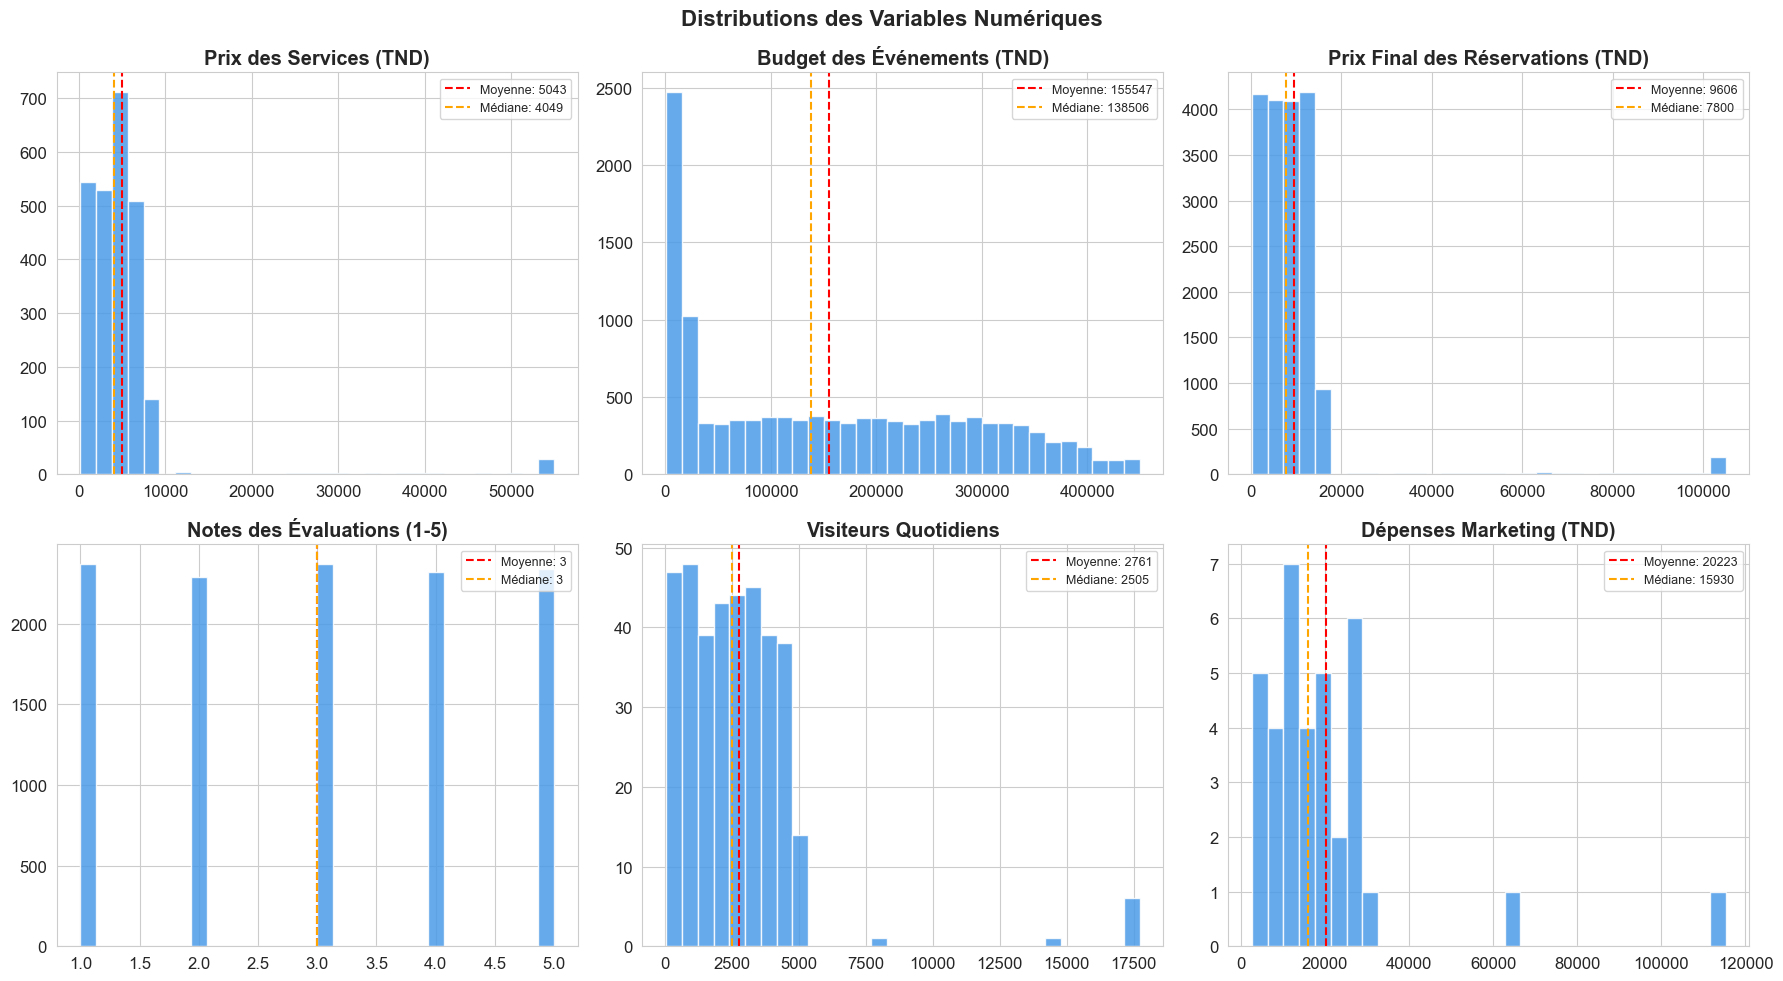

In [24]:
#Distributions des variables numériques clés
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

num_distributions = [
    (svc_clean, 'price', 'Prix des Services (TND)'),
    (event_clean, 'budget', 'Budget des Événements (TND)'),
    (res_clean, 'final_price', 'Prix Final des Réservations (TND)'),
    (evl_clean, 'rating', 'Notes des Évaluations (1-5)'),
    (vis_clean, 'visitors', 'Visiteurs Quotidiens'),
    (mkt_clean, 'marketing_spend', 'Dépenses Marketing (TND)'),
]

for ax, (df_t, col, title) in zip(axes, num_distributions):
    data = df_t[col].dropna()
    ax.hist(data, bins=30, color='#4C9BE8', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Moyenne: {data.mean():.0f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Médiane: {data.median():.0f}')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Distributions des Variables Numériques', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions_numeriques.png', bbox_inches='tight', dpi=150)
plt.show()

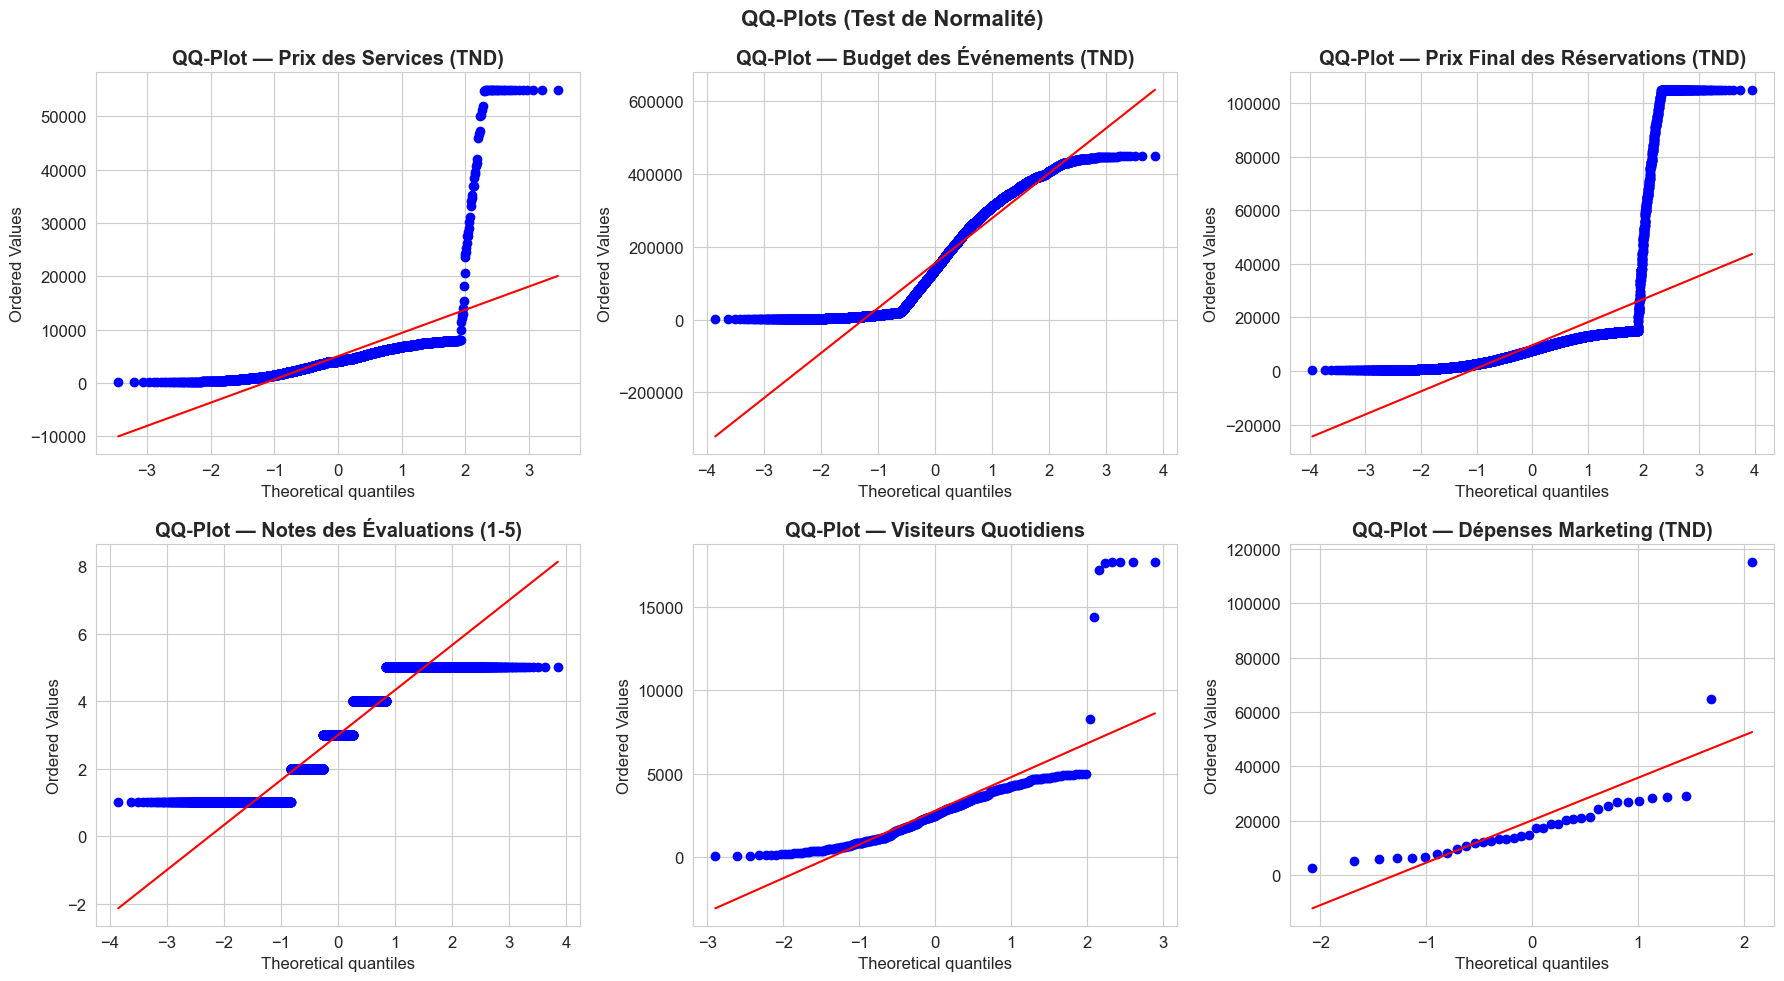

In [25]:
# QQ-Plots pour tester la normalité
from scipy.stats import probplot

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (df_t, col, title) in zip(axes, num_distributions):
    data = df_t[col].dropna()
    probplot(data, dist='norm', plot=ax)
    ax.set_title(f'QQ-Plot — {title}', fontweight='bold')

plt.suptitle('QQ-Plots (Test de Normalité)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('qqplots.png', bbox_inches='tight', dpi=150)
plt.show()

In [26]:
# Tests de Shapiro-Wilk (normalité)
from scipy.stats import shapiro

print('📐 TEST DE NORMALITÉ — SHAPIRO-WILK (p > 0.05 → normale)\n')
for df_t, col, title in num_distributions:
    data = df_t[col].dropna().sample(min(5000, len(df_t)), random_state=42)
    stat, p = shapiro(data)
    result = '✅ Normale' if p > 0.05 else '❌ Non-normale'
    print(f'  {result}  {title:40s}  stat={stat:.4f}  p={p:.6f}')

📐 TEST DE NORMALITÉ — SHAPIRO-WILK (p > 0.05 → normale)

  ❌ Non-normale  Prix des Services (TND)                   stat=0.4068  p=0.000000
  ❌ Non-normale  Budget des Événements (TND)               stat=0.9070  p=0.000000
  ❌ Non-normale  Prix Final des Réservations (TND)         stat=0.4141  p=0.000000
  ❌ Non-normale  Notes des Évaluations (1-5)               stat=0.8874  p=0.000000
  ❌ Non-normale  Visiteurs Quotidiens                      stat=0.6580  p=0.000000
  ❌ Non-normale  Dépenses Marketing (TND)                  stat=0.6107  p=0.000000


### 4.3 — Analyse temporelle

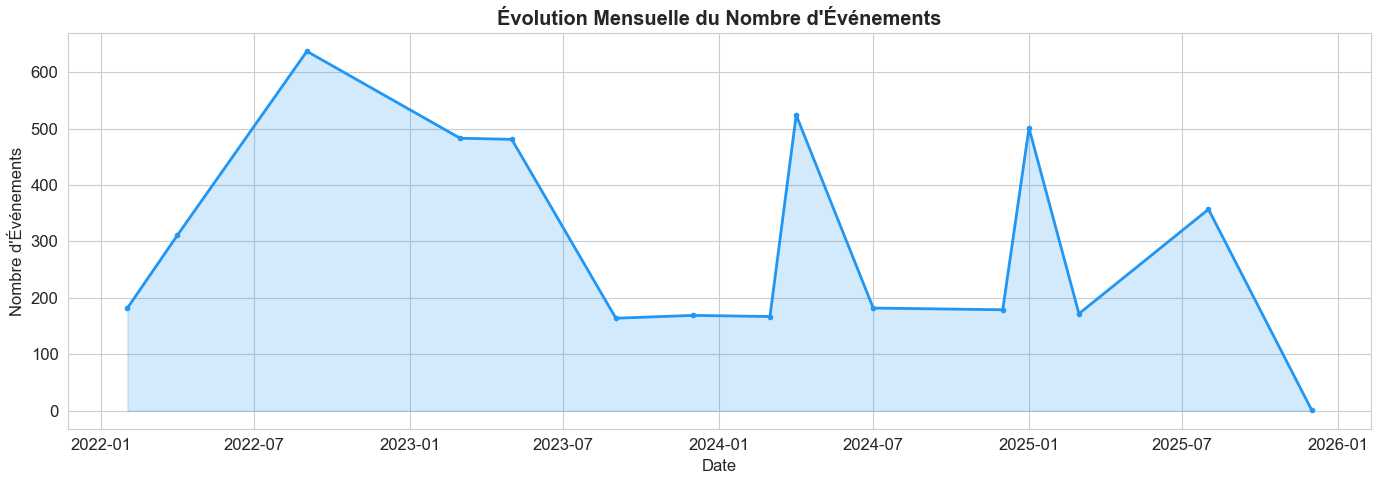

In [27]:
#Événements par mois
events_by_month = event_clean.groupby(['year', 'month']).size().reset_index(name='count')
events_by_month['date'] = pd.to_datetime(events_by_month[['year', 'month']].assign(day=1))
events_by_month = events_by_month.sort_values('date')

plt.figure(figsize=(14, 5))
plt.plot(events_by_month['date'], events_by_month['count'],
         color='#2196F3', linewidth=2, marker='o', markersize=3)
plt.fill_between(events_by_month['date'], events_by_month['count'], alpha=0.2, color='#2196F3')
plt.title('Évolution Mensuelle du Nombre d\'Événements', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Nombre d\'Événements')
plt.tight_layout()
plt.savefig('events_timeline.png', bbox_inches='tight', dpi=150)
plt.show()

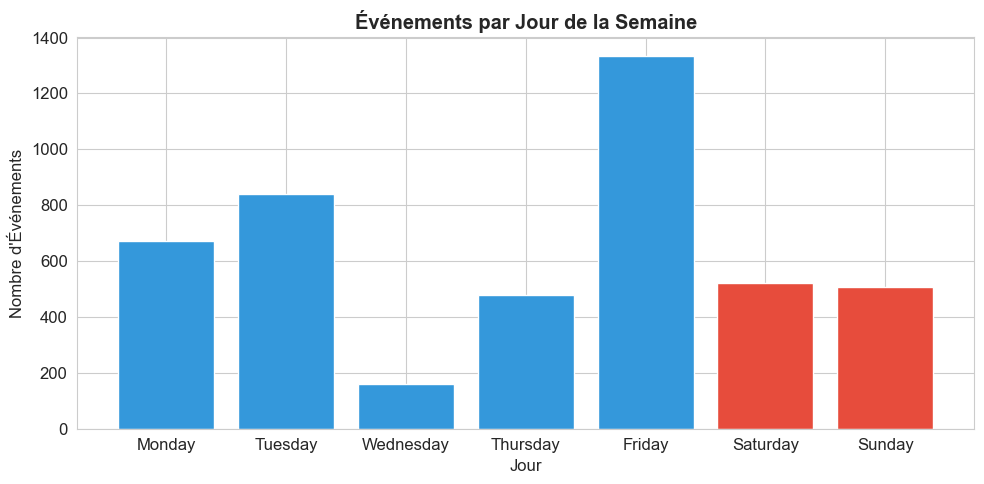

In [28]:
#Événements par jour de la semaine
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = event_clean['weekday'].value_counts().reindex(weekday_order)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if d in ['Saturday', 'Sunday'] else '#3498db' for d in weekday_order]
plt.bar(weekday_counts.index, weekday_counts.values, color=colors)
plt.title('Événements par Jour de la Semaine', fontweight='bold')
plt.xlabel('Jour')
plt.ylabel('Nombre d\'Événements')
plt.tight_layout()
plt.savefig('events_weekday.png', bbox_inches='tight', dpi=150)
plt.show()

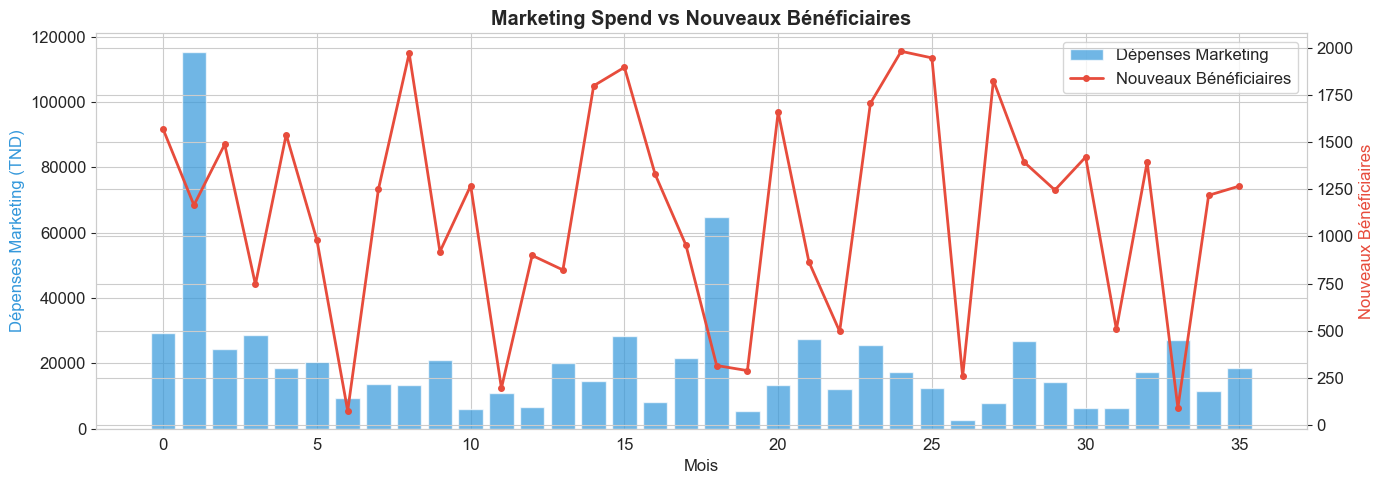

In [29]:
#Dépenses marketing vs nouveaux bénéficiaires
fig, ax1 = plt.subplots(figsize=(14, 5))

ax2 = ax1.twinx()
ax1.bar(range(len(mkt_clean)), mkt_clean['marketing_spend'],
        color='#3498db', alpha=0.7, label='Dépenses Marketing')
ax2.plot(range(len(mkt_clean)), mkt_clean['new_beneficiaries'],
         color='#e74c3c', linewidth=2, marker='o', markersize=4, label='Nouveaux Bénéficiaires')

ax1.set_xlabel('Mois')
ax1.set_ylabel('Dépenses Marketing (TND)', color='#3498db')
ax2.set_ylabel('Nouveaux Bénéficiaires', color='#e74c3c')
plt.title('Marketing Spend vs Nouveaux Bénéficiaires', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('marketing_vs_beneficiaries.png', bbox_inches='tight', dpi=150)
plt.show()

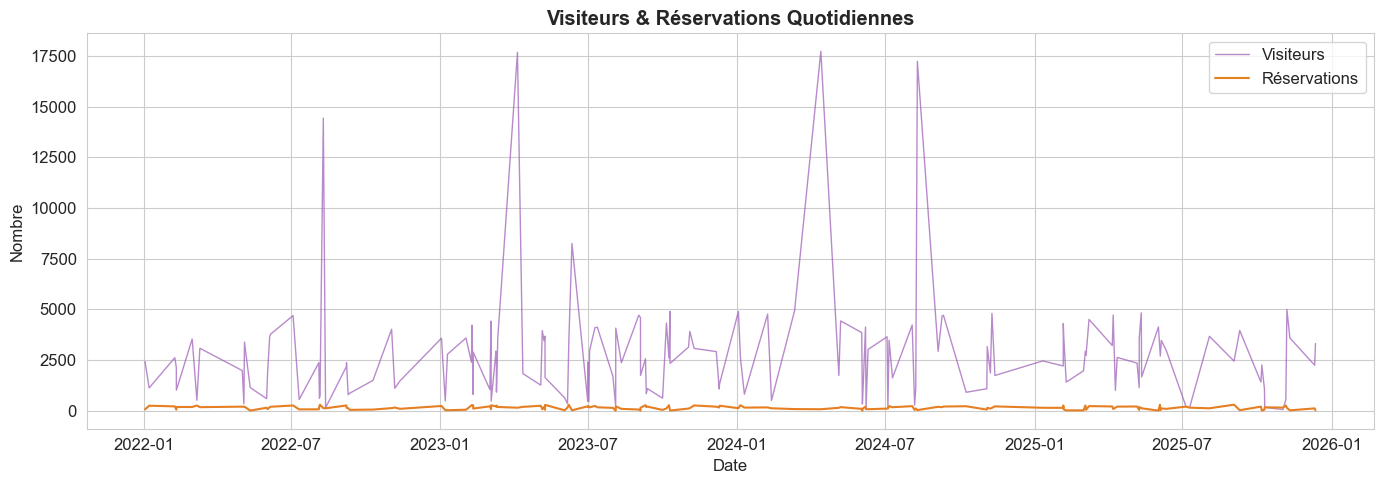

In [30]:
#Visiteurs vs Réservations (table VISITORS)
plt.figure(figsize=(14, 5))
vis_sorted = vis_clean_dates.sort_values('date')

plt.plot(vis_sorted['date'], vis_sorted['visitors'],
         label='Visiteurs', color='#9b59b6', alpha=0.7, linewidth=1)
plt.plot(vis_sorted['date'], vis_sorted['reservations'],
         label='Réservations', color='#e67e22', linewidth=1.5)
plt.title('Visiteurs & Réservations Quotidiennes', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Nombre')
plt.legend()
plt.tight_layout()
plt.savefig('visitors_reservations.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.4 — Analyse croisée (Cross-Analysis)

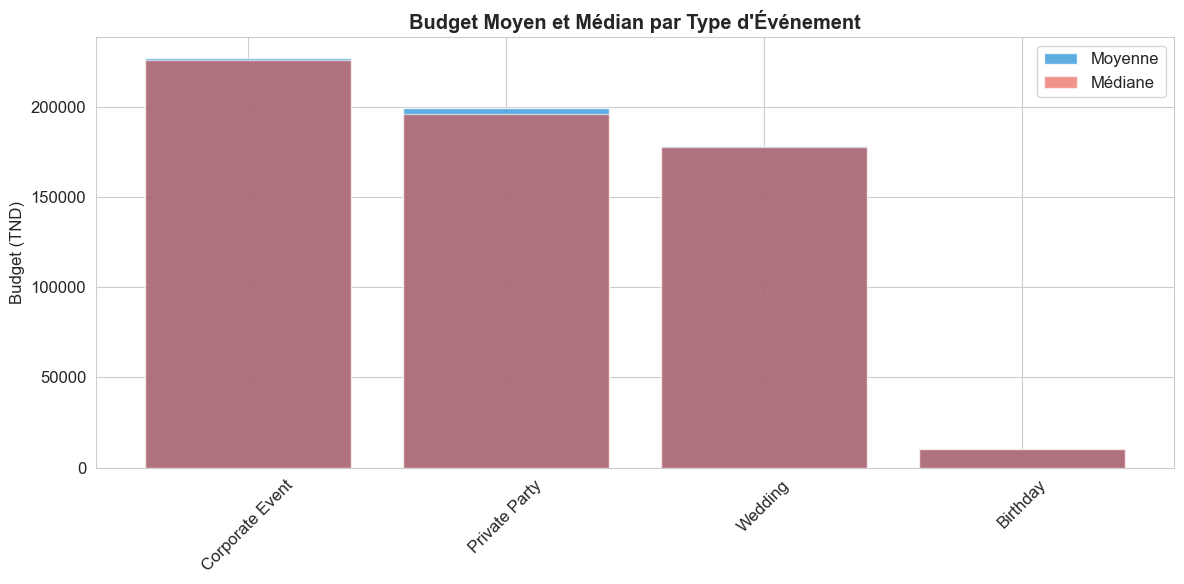

,Moyenne,Médiane,Écart-Type
type,,,
Corporate Event,227041.0,225798.0,126119.0
Private Party,199201.0,195784.0,113672.0
Wedding,178308.0,177842.0,99334.0
Birthday,10558.0,10606.0,5495.0


In [31]:
#Budget moyen par type d'événement
budget_by_type = event_clean.groupby('type')['budget'].agg(['mean', 'median', 'std']).round(0)
budget_by_type.columns = ['Moyenne', 'Médiane', 'Écart-Type']
budget_by_type = budget_by_type.sort_values('Moyenne', ascending=False)

plt.figure(figsize=(12, 6))
x = range(len(budget_by_type))
plt.bar(x, budget_by_type['Moyenne'], color='#3498db', alpha=0.8, label='Moyenne')
plt.bar(x, budget_by_type['Médiane'], color='#e74c3c', alpha=0.6, label='Médiane')
plt.xticks(x, budget_by_type.index, rotation=45)
plt.title('Budget Moyen et Médian par Type d\'Événement', fontweight='bold')
plt.ylabel('Budget (TND)')
plt.legend()
plt.tight_layout()
plt.savefig('budget_by_type.png', bbox_inches='tight', dpi=150)
plt.show()

display(budget_by_type)

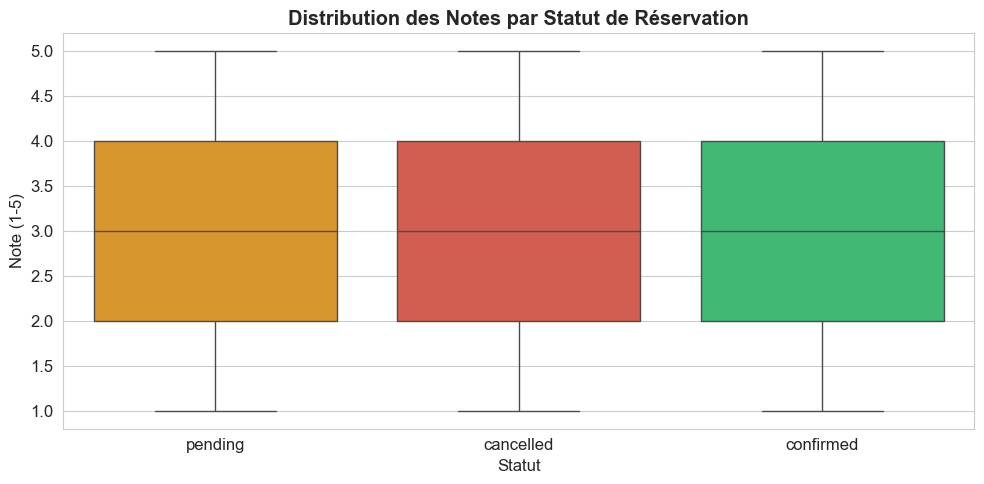

In [32]:
#Note moyenne par statut de réservation
merged_eval = evl_clean.merge(res_clean_dates[['id_reservation', 'status', 'final_price']],
                               on='id_reservation', how='inner')

plt.figure(figsize=(10, 5))
sns.boxplot(data=merged_eval, x='status', y='rating',
            palette={'confirmed': '#2ecc71', 'pending': '#f39c12', 'cancelled': '#e74c3c'})
plt.title('Distribution des Notes par Statut de Réservation', fontweight='bold')
plt.xlabel('Statut')
plt.ylabel('Note (1-5)')
plt.tight_layout()
plt.savefig('rating_by_status.png', bbox_inches='tight', dpi=150)
plt.show()

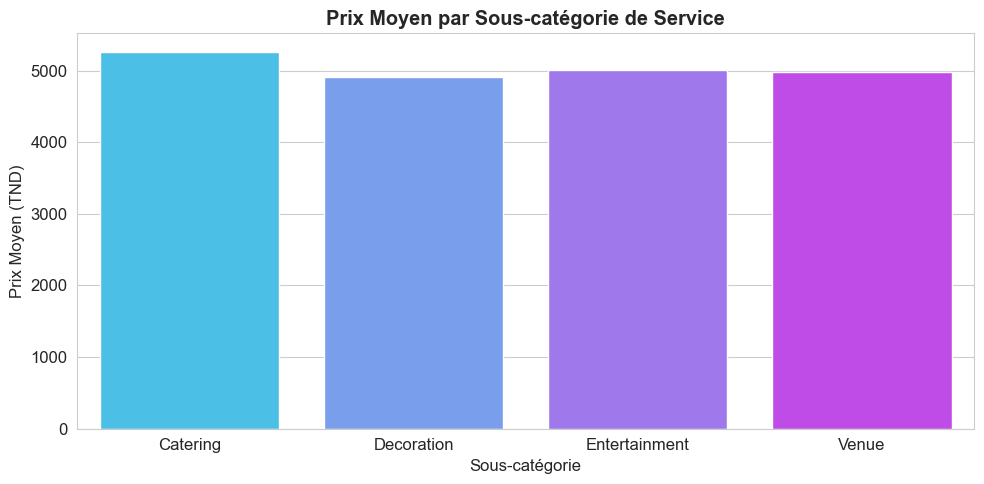

,Sous-catégorie,Prix Moyen,Nb Services
0,Catering,5259.597456,629
1,Decoration,4916.039906,639
2,Entertainment,5007.798013,604
3,Venue,4989.256688,628


In [33]:
# Prix moyen par sous-catégorie de service
svc_subcat = svc_clean.merge(subcategory[['id_subcategory', 'name']], on='id_subcategory')
price_by_subcat = svc_subcat.groupby('name')['price'].agg(['mean', 'count']).reset_index()
price_by_subcat.columns = ['Sous-catégorie', 'Prix Moyen', 'Nb Services']

plt.figure(figsize=(10, 5))
sns.barplot(data=price_by_subcat, x='Sous-catégorie', y='Prix Moyen', palette='cool')
plt.title('Prix Moyen par Sous-catégorie de Service', fontweight='bold')
plt.ylabel('Prix Moyen (TND)')
plt.tight_layout()
plt.savefig('price_by_subcategory.png', bbox_inches='tight', dpi=150)
plt.show()

display(price_by_subcat)

## 🔗 5. Matrice de Corrélation & Feature Selection

In [34]:
#Construction de la table analytique principale (Master Table)
# Jointures : EVENT → RESERVATION → EVALUATION
master = event_clean.merge(
    res_clean_dates[['id_reservation', 'id_event', 'id_service', 'status', 'final_price']],
    on='id_event', how='left'
).merge(
    evl_clean[['id_reservation', 'rating']],
    on='id_reservation', how='left'
).merge(
    svc_clean[['id_service', 'price', 'id_provider', 'id_subcategory']],
    on='id_service', how='left'
)

# Encodage des catégories
le_type   = LabelEncoder()
le_status = LabelEncoder()
master['type_enc']   = le_type.fit_transform(master['type'].fillna('Unknown'))
master['status_enc'] = le_status.fit_transform(master['status'].fillna('Unknown'))

print(f'✅ Master table créée : {master.shape}')
display(master.head(3))

✅ Master table créée : (23767, 20)


,id_event,title,event_date,budget,type,id_beneficiary,year,month,weekday,quarter,id_reservation,id_service,status,final_price,rating,price,id_provider,id_subcategory,type_enc,status_enc
0,1730,Common special.,2022-04-01 00:12:37,205052,Corporate Event,3590,2022.0,4.0,Friday,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
1,21,Simply manager.,2022-04-01 00:22:33,45900,Corporate Event,3699,2022.0,4.0,Friday,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
2,8872,Enjoy ahead collection.,2022-04-01 00:36:12,429833,Corporate Event,1596,2022.0,4.0,Friday,2.0,9666.0,1555.0,confirmed,345.0,NaN,3704.0,214.0,1.0,1,2


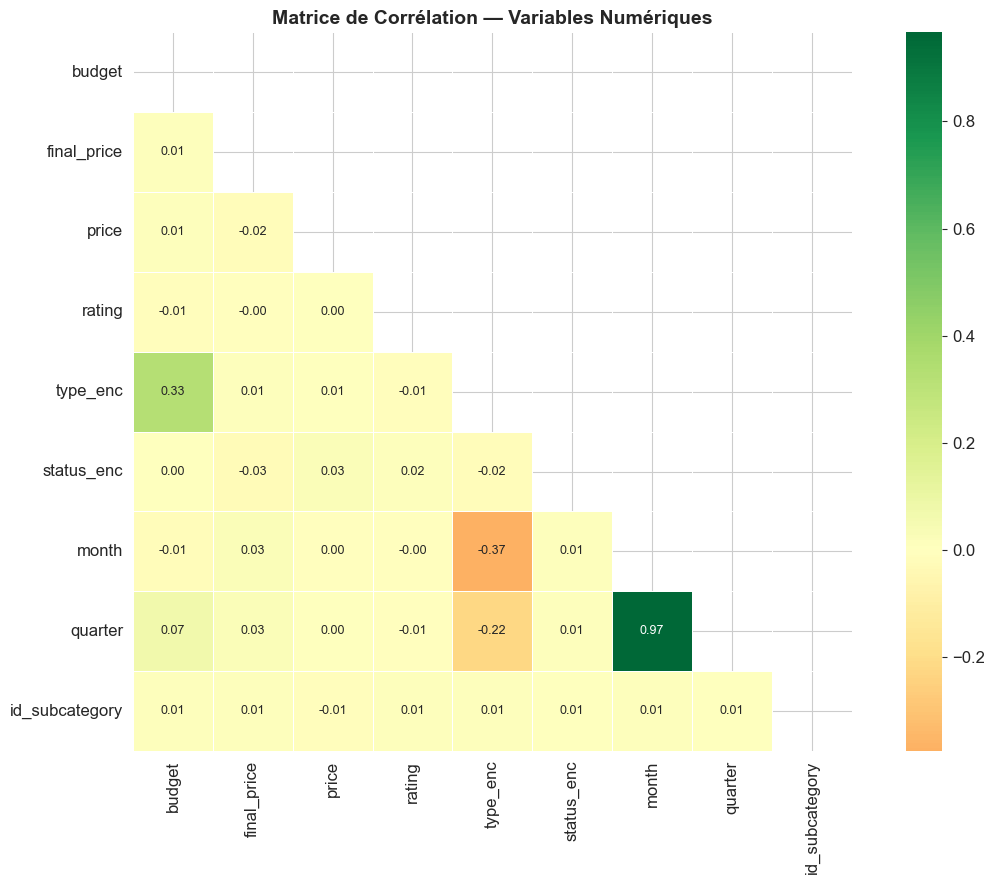

In [35]:
#  Matrice de corrélation (variables numériques)
corr_cols = ['budget', 'final_price', 'price', 'rating', 'type_enc', 'status_enc',
             'month', 'quarter', 'id_subcategory']

corr_matrix = master[corr_cols].dropna().corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, linewidths=0.5,
            annot_kws={'size': 9}, square=True)
plt.title('Matrice de Corrélation — Variables Numériques', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

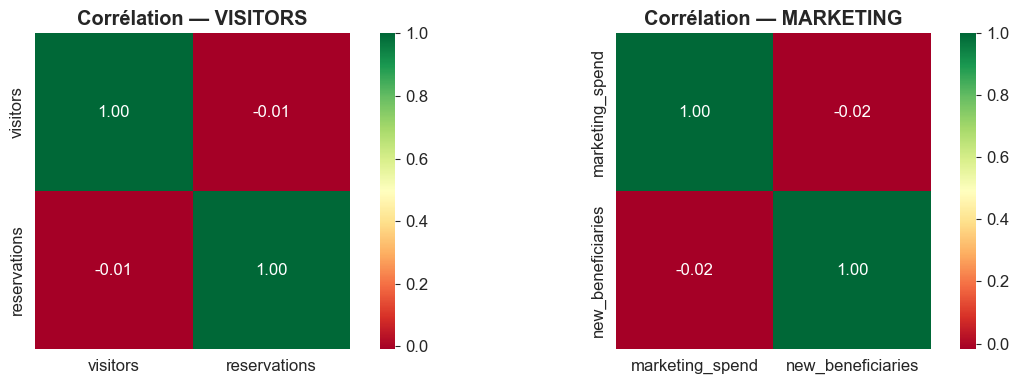

In [36]:
#Heatmap corrélation VISITORS & MARKETING
vis_corr = vis_clean[['visitors', 'reservations']].corr()
mkt_corr = mkt_clean[['marketing_spend', 'new_beneficiaries']].corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(vis_corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0], square=True)
axes[0].set_title('Corrélation — VISITORS', fontweight='bold')
sns.heatmap(mkt_corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1], square=True)
axes[1].set_title('Corrélation — MARKETING', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_visitors_marketing.png', bbox_inches='tight', dpi=150)
plt.show()

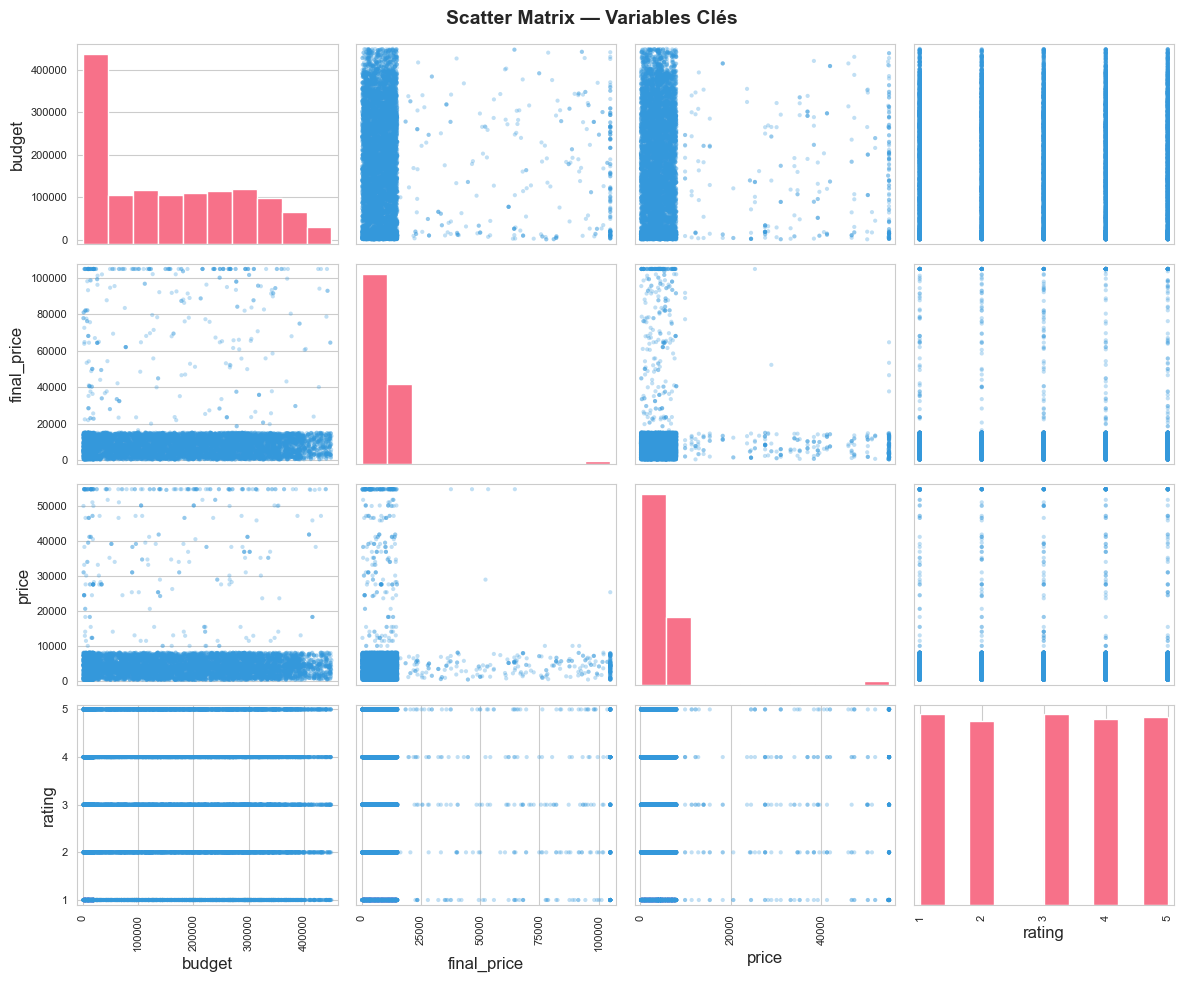

In [37]:
#  Scatter plots des paires corrélées
from pandas.plotting import scatter_matrix

scatter_cols = ['budget', 'final_price', 'price', 'rating']
scatter_data = master[scatter_cols].dropna()

scatter_matrix(scatter_data, alpha=0.3, figsize=(12, 10), diagonal='hist',
               color='#3498db')
plt.suptitle('Scatter Matrix — Variables Clés', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.1 — Feature Selection

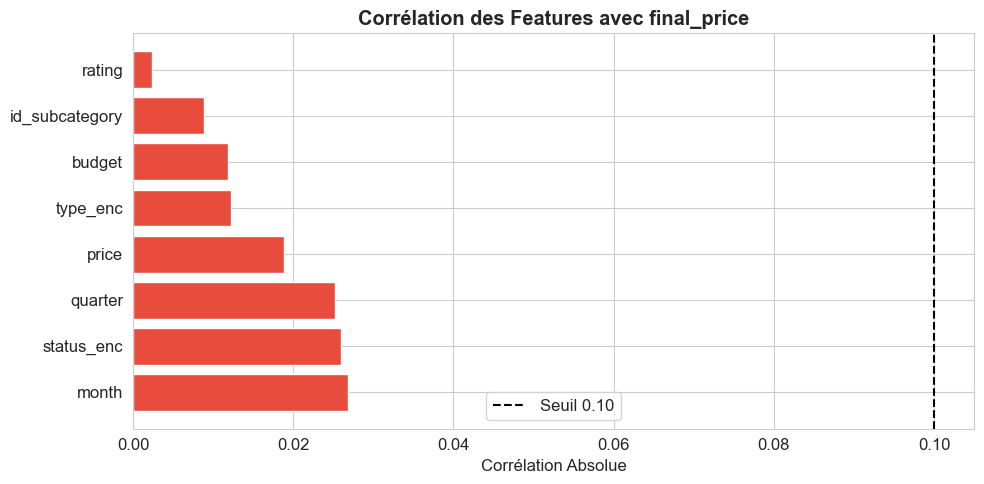


Features sélectionnées (corrélation > 0.10 avec final_price) :


Series([], Name: final_price, dtype: float64)

In [38]:
#Méthode 1 : Corrélation avec la target (final_price)
target = 'final_price'
features_corr = master[corr_cols].dropna().corr()[target].drop(target).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if v >= 0.1 else '#e74c3c' for v in features_corr.values]
plt.barh(features_corr.index, features_corr.values, color=colors)
plt.axvline(x=0.1, color='black', linestyle='--', linewidth=1.5, label='Seuil 0.10')
plt.title(f'Corrélation des Features avec {target}', fontweight='bold')
plt.xlabel('Corrélation Absolue')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance_corr.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nFeatures sélectionnées (corrélation > 0.10 avec {target}) :')
selected = features_corr[features_corr >= 0.10]
display(selected)

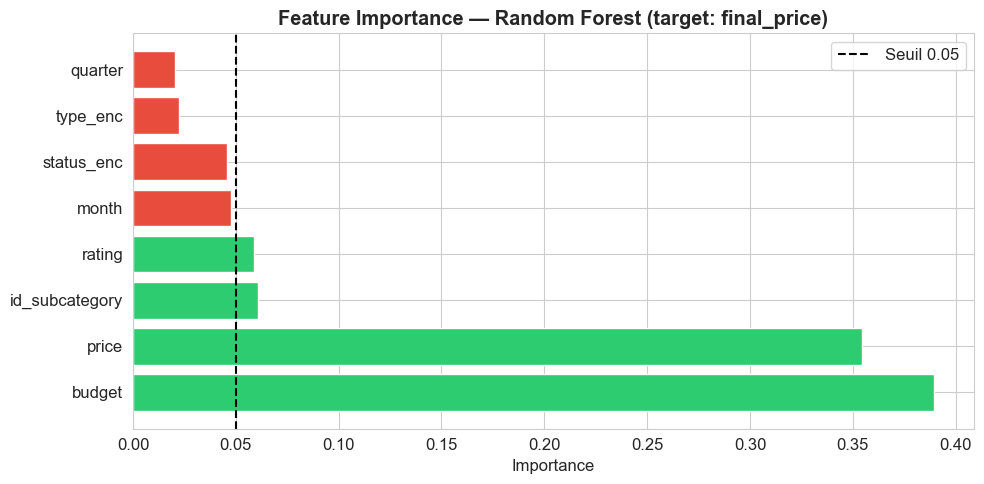


R² sur test set : 0.1479


In [39]:
# Méthode 2 : Random Forest Feature Importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

feature_cols = ['budget', 'price', 'rating', 'type_enc', 'status_enc', 'month', 'quarter', 'id_subcategory']
ml_data = master[feature_cols + [target]].dropna()

X = ml_data[feature_cols]
y = ml_data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if v >= 0.05 else '#e74c3c' for v in importances.values]
plt.barh(importances.index, importances.values, color=colors)
plt.axvline(x=0.05, color='black', linestyle='--', label='Seuil 0.05')
plt.title('Feature Importance — Random Forest (target: final_price)', fontweight='bold')
plt.xlabel('Importance')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance_rf.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nR² sur test set : {rf.score(X_test, y_test):.4f}')

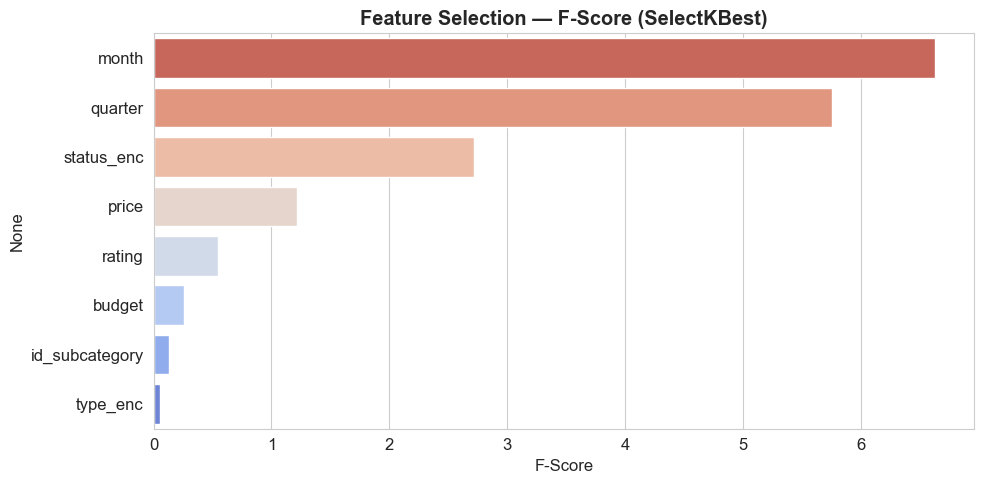


Top 5 features retenues par F-Score :
month         6.630236
quarter       5.759590
status_enc    2.716482
price         1.217143
rating        0.550992


In [40]:
#Méthode 3 : SelectKBest (F-score)
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train, y_train)

f_scores = pd.Series(selector.scores_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=f_scores.values, y=f_scores.index, palette='coolwarm_r')
plt.title('Feature Selection — F-Score (SelectKBest)', fontweight='bold')
plt.xlabel('F-Score')
plt.tight_layout()
plt.savefig('feature_selection_fscore.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nTop 5 features retenues par F-Score :')
print(f_scores.head(5).to_string())

In [41]:
# Résumé : Features sélectionnées
print('━'*60)
print('🎯 RÉCAPITULATIF — FEATURES SÉLECTIONNÉES')
print('━'*60)

# Top 5 par chaque méthode
top_corr = set(features_corr[features_corr >= 0.10].index.tolist())
top_rf   = set(importances[importances >= 0.05].index.tolist())
top_f    = set(f_scores.head(5).index.tolist())

final_features = top_corr & top_rf  # Intersection des deux méthodes principales

print(f'\n  Corrélation (≥0.10)     : {sorted(top_corr)}')
print(f'  Random Forest (≥0.05)   : {sorted(top_rf)}')
print(f'  F-Score (top 5)         : {sorted(top_f)}')
print(f'\n  ✅ Features finales     : {sorted(final_features)}')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 RÉCAPITULATIF — FEATURES SÉLECTIONNÉES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Corrélation (≥0.10)     : []
  Random Forest (≥0.05)   : ['budget', 'id_subcategory', 'price', 'rating']
  F-Score (top 5)         : ['month', 'price', 'quarter', 'rating', 'status_enc']

  ✅ Features finales     : []


## 🎨 6. Visualisations Avancées

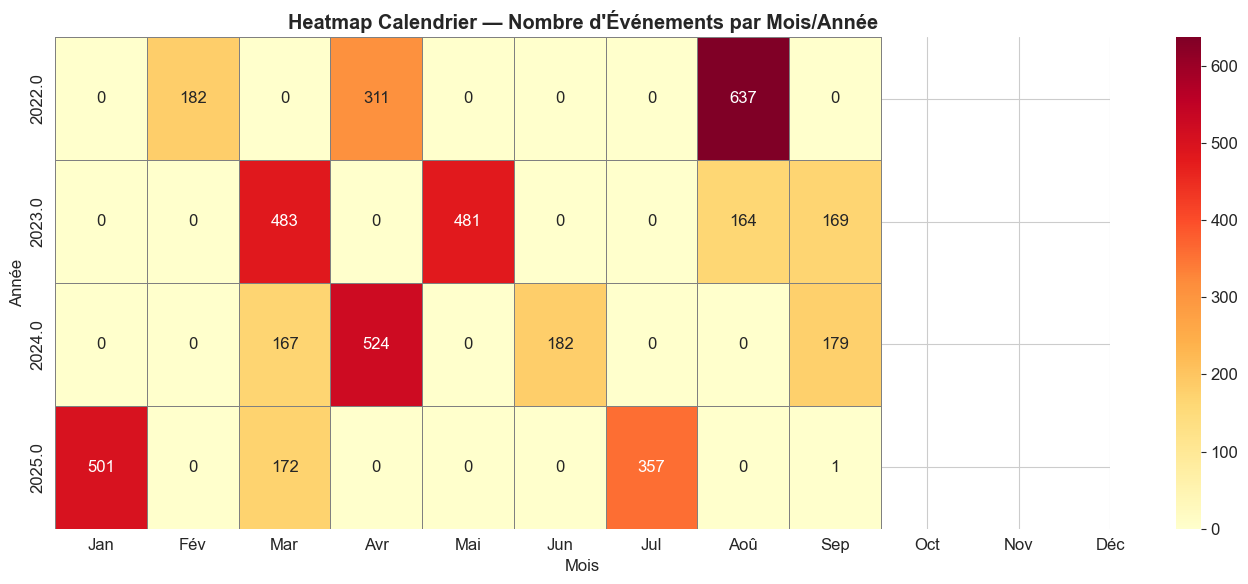

In [42]:
# Heatmap calendrier : Événements par mois/année
pivot = event_clean.groupby(['year', 'month']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, linecolor='gray',
            xticklabels=['Jan','Fév','Mar','Avr','Mai','Jun',
                         'Jul','Aoû','Sep','Oct','Nov','Déc'])
plt.title('Heatmap Calendrier — Nombre d\'Événements par Mois/Année', fontweight='bold')
plt.xlabel('Mois')
plt.ylabel('Année')
plt.tight_layout()
plt.savefig('heatmap_calendar.png', bbox_inches='tight', dpi=150)
plt.show()

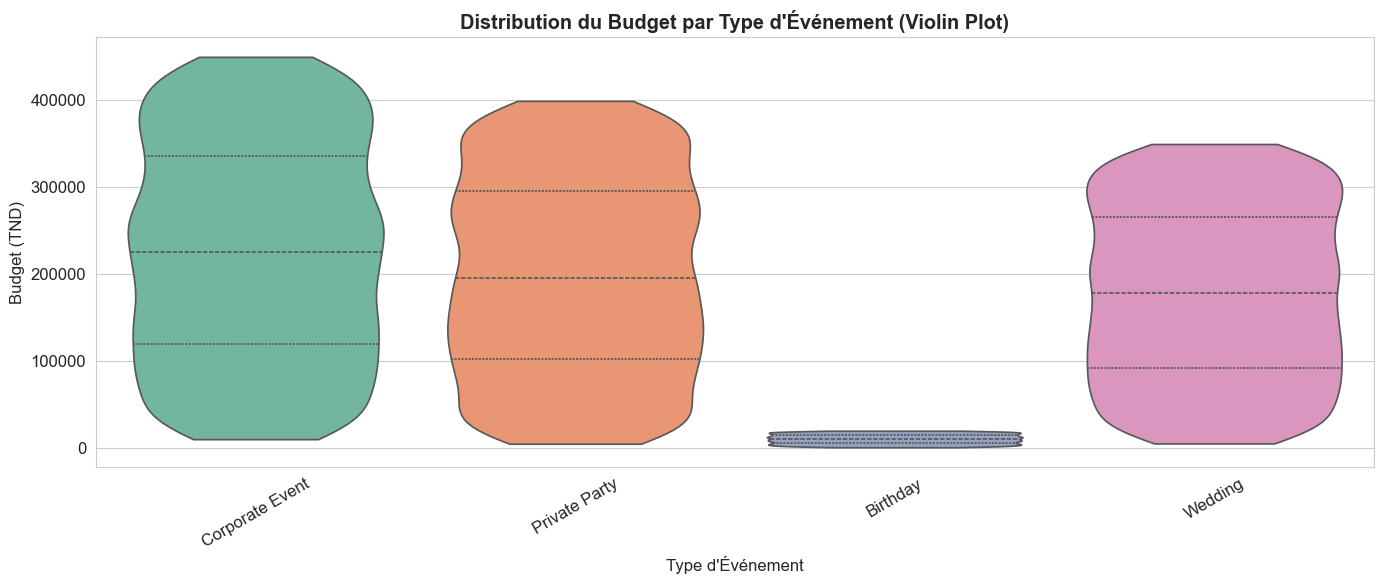

In [43]:
#Violin plots : Budget par type d'événement
plt.figure(figsize=(14, 6))
sns.violinplot(data=event_clean, x='type', y='budget',
               palette='Set2', inner='quartile', cut=0)
plt.title('Distribution du Budget par Type d\'Événement (Violin Plot)', fontweight='bold')
plt.xlabel('Type d\'Événement')
plt.ylabel('Budget (TND)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('violin_budget.png', bbox_inches='tight', dpi=150)
plt.show()

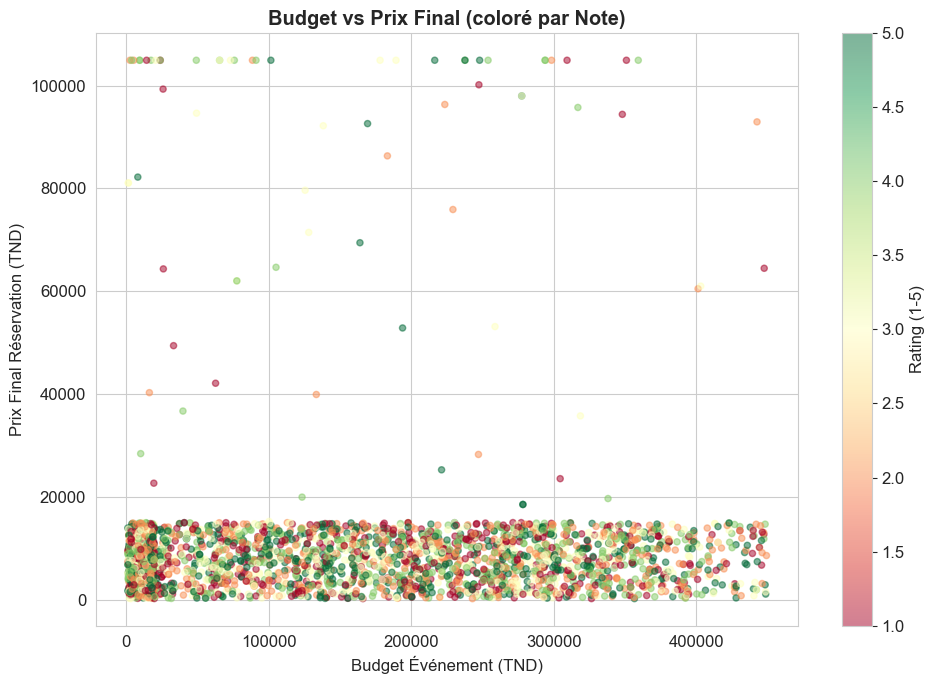

In [44]:
# Scatter : Budget vs Final Price coloré par Rating
plot_data = master[['budget', 'final_price', 'rating']].dropna().sample(3000, random_state=42)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(plot_data['budget'], plot_data['final_price'],
                      c=plot_data['rating'], cmap='RdYlGn',
                      alpha=0.5, s=20, vmin=1, vmax=5)
plt.colorbar(scatter, label='Rating (1-5)')
plt.title('Budget vs Prix Final (coloré par Note)', fontweight='bold')
plt.xlabel('Budget Événement (TND)')
plt.ylabel('Prix Final Réservation (TND)')
plt.tight_layout()
plt.savefig('scatter_budget_price_rating.png', bbox_inches='tight', dpi=150)
plt.show()

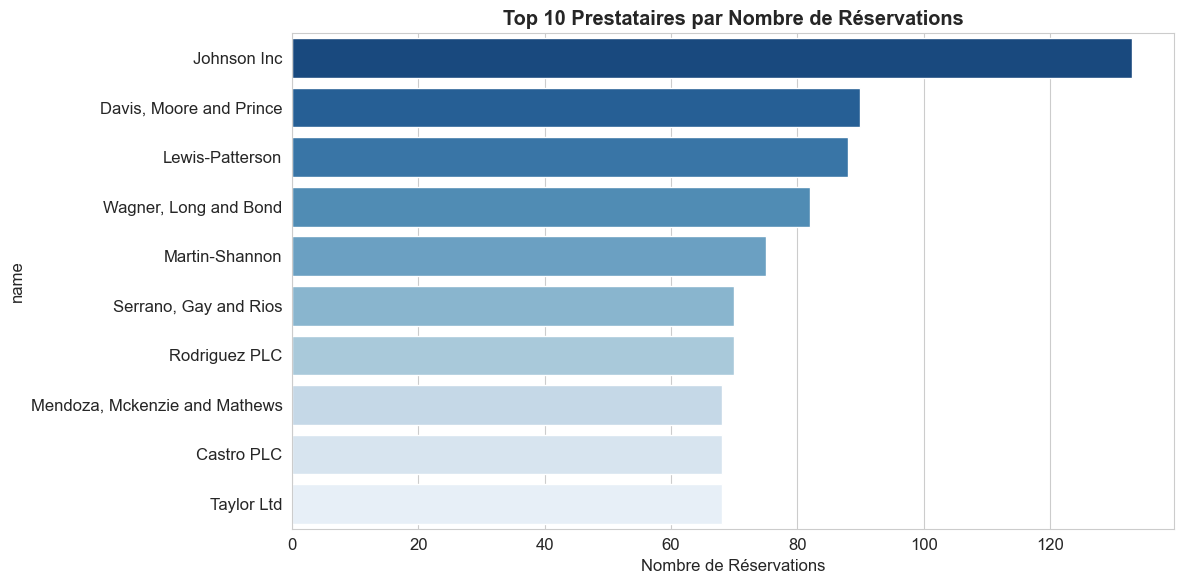

In [45]:
# Top 10 prestataires par nombre de réservations
top_providers = (
    res_clean_dates
    .merge(svc_clean[['id_service', 'id_provider']], on='id_service')
    .merge(provider[['id_provider', 'name']], on='id_provider')
    .groupby('name')['id_reservation'].count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_providers.values, y=top_providers.index, palette='Blues_r')
plt.title('Top 10 Prestataires par Nombre de Réservations', fontweight='bold')
plt.xlabel('Nombre de Réservations')
plt.tight_layout()
plt.savefig('top_providers.png', bbox_inches='tight', dpi=150)
plt.show()

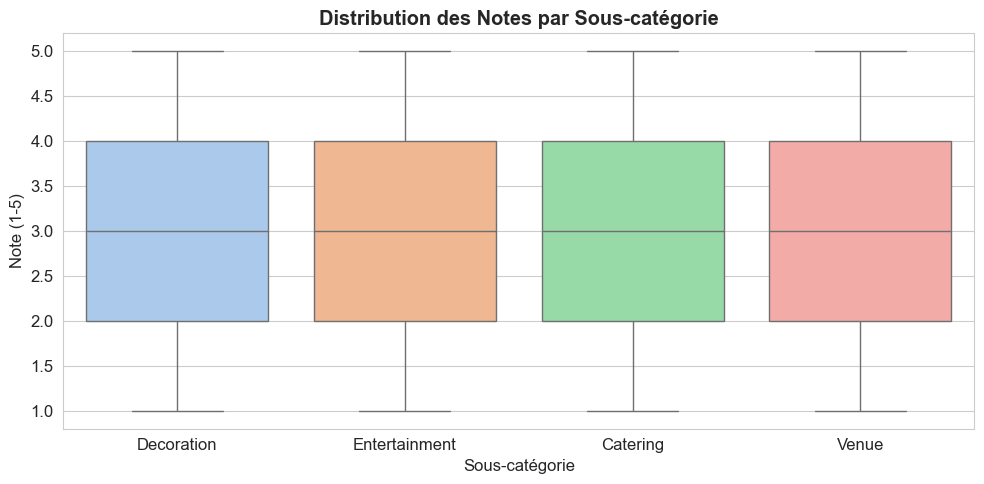

In [46]:
# Distribution des ratings par sous-catégorie
rating_subcat = (
    merged_eval
    .merge(svc_clean[['id_service', 'id_subcategory']], left_on='id_reservation', right_on='id_service', how='left')
    .merge(subcategory[['id_subcategory', 'name']], on='id_subcategory', how='left')
)
# Utilisation directe de master pour la jointure correcte
rating_sub_data = master[['rating', 'id_subcategory']].dropna()
rating_sub_data = rating_sub_data.merge(subcategory[['id_subcategory', 'name']], on='id_subcategory')

plt.figure(figsize=(10, 5))
sns.boxplot(data=rating_sub_data, x='name', y='rating', palette='pastel')
plt.title('Distribution des Notes par Sous-catégorie', fontweight='bold')
plt.xlabel('Sous-catégorie')
plt.ylabel('Note (1-5)')
plt.tight_layout()
plt.savefig('rating_by_subcategory.png', bbox_inches='tight', dpi=150)
plt.show()

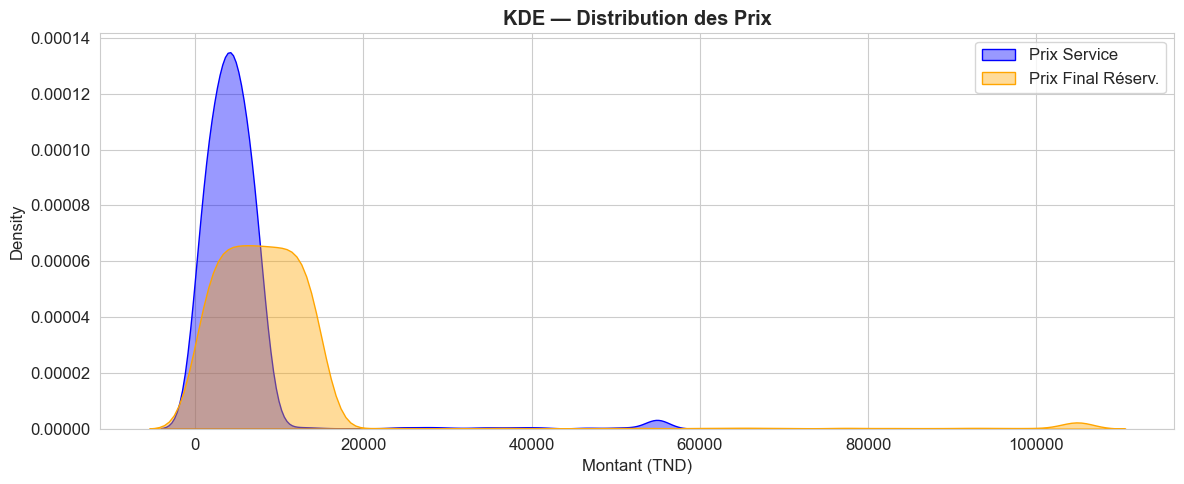

In [47]:
# KDE prix service vs prix final réservation
plt.figure(figsize=(12, 5))
sns.kdeplot(svc_clean['price'].dropna(),      label='Prix Service',      fill=True, alpha=0.4, color='blue')
sns.kdeplot(res_clean['final_price'].dropna(), label='Prix Final Réserv.', fill=True, alpha=0.4, color='orange')
plt.title('KDE — Distribution des Prix', fontweight='bold')
plt.xlabel('Montant (TND)')
plt.legend()
plt.tight_layout()
plt.show()

## 🎨 7.Valeurs manquantes → Imputer  (tu conserves toutes les données)
Outliers logiquement impossibles (rating > 5) → Supprimer

Outliers extrêmes mais possibles → Winsoriser

In [48]:
# ════════════════════════════════════════════════════
# NETTOYAGE FINAL — EVENTZELLA
# ════════════════════════════════════════════════════

print("AVANT nettoyage :")
print(f"  BENEFICIARY : {beneficiary.shape}")
print(f"  SERVICE     : {service.shape}")
print(f"  EVALUATION  : {evaluation.shape}")
print(f"  RESERVATION : {reservation.shape}")

AVANT nettoyage :
  BENEFICIARY : (5000, 5)
  SERVICE     : (2500, 6)
  EVALUATION  : (12000, 4)
  RESERVATION : (18000, 6)


In [49]:
# ── VALEURS MANQUANTES ───────────────────────────────
ben  = beneficiary.copy()
prov = provider.copy()
svc  = service.copy()
evl  = evaluation.copy()

# BENEFICIARY — texte → remplacer
ben['last_name'].fillna('Unknown', inplace=True)
ben['email'].fillna('no_email@unknown.com', inplace=True)

# PROVIDER — texte → remplacer
prov['email'].fillna('no_email@provider.com', inplace=True)

# SERVICE — price numérique → médiane par groupe
svc['price'] = svc.groupby('id_subcategory')['price'].transform(
    lambda x: x.fillna(x.median())
)
svc['price'].fillna(svc['price'].median(), inplace=True)
svc['title'].fillna('No Title', inplace=True)

# EVALUATION — texte → remplacer
evl['comment'].fillna('No Comment', inplace=True)

print("✅ Valeurs manquantes traitées")
for name, df in [('BENEFICIARY',ben),('PROVIDER',prov),('SERVICE',svc),('EVALUATION',evl)]:
    print(f"  {name:15s} → {df.isnull().sum().sum()} NaN restants")

✅ Valeurs manquantes traitées
  BENEFICIARY     → 0 NaN restants
  PROVIDER        → 0 NaN restants
  SERVICE         → 0 NaN restants
  EVALUATION      → 0 NaN restants


In [50]:
# ── OUTLIERS ─────────────────────────────────────────

# 1. EVALUATION.rating > 5 → SUPPRIMER (erreur logique)
avant = len(evl)
evl = evl[evl['rating'] <= 5]
print(f"EVALUATION : {avant - len(evl)} lignes supprimées (rating > 5)")

# 2. Winsorisation pour les autres (valeurs extrêmes mais réelles)
svc_clean = svc.copy()
res_clean = reservation.copy()
vis_clean = visitors.copy()
mkt_clean = marketing.copy()

svc_clean['price']           = svc_clean['price'].clip(upper=svc_clean['price'].quantile(0.99))
res_clean['final_price']     = res_clean['final_price'].clip(upper=res_clean['final_price'].quantile(0.99))
vis_clean['visitors']        = vis_clean['visitors'].clip(upper=vis_clean['visitors'].quantile(0.99))
mkt_clean['marketing_spend'] = mkt_clean['marketing_spend'].clip(upper=mkt_clean['marketing_spend'].quantile(0.99))

event_clean = event.copy()
event_clean['event_date'] = pd.to_datetime(event_clean['event_date'], errors='coerce')
event_clean['year']    = event_clean['event_date'].dt.year
event_clean['month']   = event_clean['event_date'].dt.month
event_clean['quarter'] = event_clean['event_date'].dt.quarter
event_clean['weekday'] = event_clean['event_date'].dt.day_name()

print("✅ Outliers traités (winsorisation + suppression rating > 5)")

EVALUATION : 312 lignes supprimées (rating > 5)
✅ Outliers traités (winsorisation + suppression rating > 5)


In [51]:
# ── CONSTRUCTION MASTER TABLE ────────────────────────
master = event_clean.merge(
    res_clean[['id_reservation','id_event','id_service','status','final_price']],
    on='id_event', how='left'
).merge(
    evl[['id_reservation','rating']], on='id_reservation', how='left'
).merge(
    svc_clean[['id_service','price','id_provider','id_subcategory']], on='id_service', how='left'
)

le = LabelEncoder()
master['type_enc']   = le.fit_transform(master['type'].fillna('Unknown'))
master['status_enc'] = le.fit_transform(master['status'].fillna('Unknown'))

print(f"✅ Master table : {master.shape}")

✅ Master table : (23767, 20)


In [52]:
# ── SUPPRESSION DES NaN RESTANTS pour ML/Corrélation ─
corr_cols     = ['budget','final_price','price','rating',
                 'type_enc','status_enc','month','quarter','id_subcategory']
feature_cols  = ['budget','price','rating','type_enc',
                 'status_enc','month','quarter','id_subcategory']
target        = 'final_price'

master_ml = master[corr_cols].dropna().reset_index(drop=True)

print(f"Master table complète  : {master.shape[0]:,} lignes")
print(f"Master table pour ML   : {master_ml.shape[0]:,} lignes")
print(f"Lignes retirées (NaN)  : {master.shape[0] - master_ml.shape[0]:,} lignes")
print(f"% conservé             : {master_ml.shape[0]/master.shape[0]*100:.1f}%")

Master table complète  : 23,767 lignes
Master table pour ML   : 4,471 lignes
Lignes retirées (NaN)  : 19,296 lignes
% conservé             : 18.8%


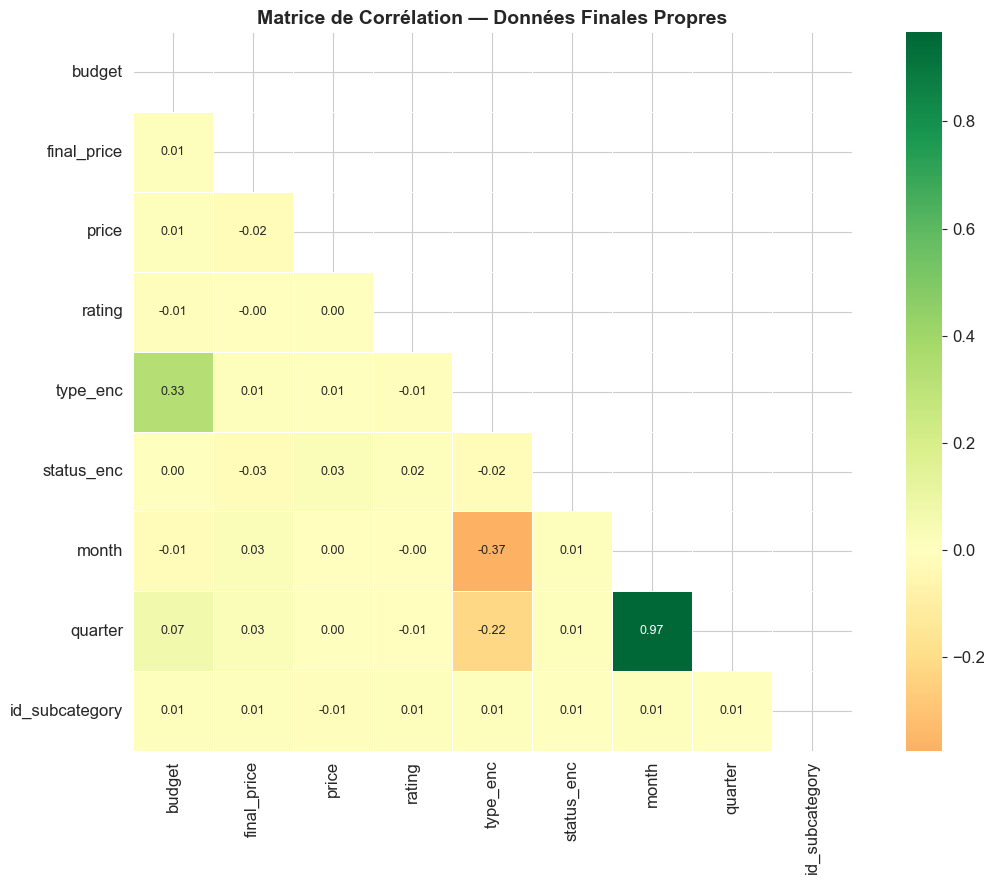

In [53]:
# ── MATRICE DE CORRÉLATION FINALE ────────────────────
corr_matrix = master_ml.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, linewidths=0.5,
            annot_kws={'size':9}, square=True)
plt.title('Matrice de Corrélation — Données Finales Propres', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

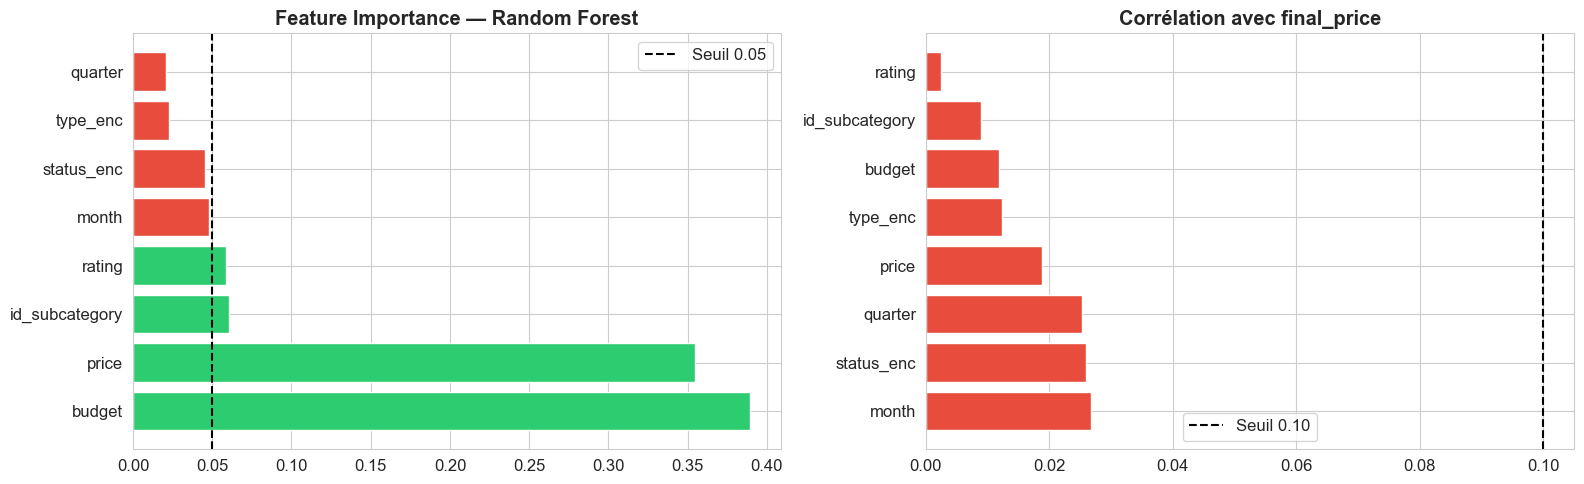


R² Random Forest : 0.1479

Features retenues (RF >= 0.05) : ['budget', 'price', 'id_subcategory', 'rating']
Features retenues (Corr >= 0.10): []


In [54]:
# ── FEATURE SELECTION FINALE ─────────────────────────
X = master_ml[feature_cols]
y = master_ml[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 : RF Importance
colors = ['#2ecc71' if v >= 0.05 else '#e74c3c' for v in importances.values]
axes[0].barh(importances.index, importances.values, color=colors)
axes[0].axvline(x=0.05, color='black', linestyle='--', label='Seuil 0.05')
axes[0].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[0].legend()

# Plot 2 : Corrélation avec target
feat_corr = corr_matrix[target].drop(target).abs().sort_values(ascending=False)
colors2 = ['#2ecc71' if v >= 0.1 else '#e74c3c' for v in feat_corr.values]
axes[1].barh(feat_corr.index, feat_corr.values, color=colors2)
axes[1].axvline(x=0.1, color='black', linestyle='--', label='Seuil 0.10')
axes[1].set_title(f'Corrélation avec {target}', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nR² Random Forest : {rf.score(X_test, y_test):.4f}')
print(f'\nFeatures retenues (RF >= 0.05) : {list(importances[importances >= 0.05].index)}')
print(f'Features retenues (Corr >= 0.10): {list(feat_corr[feat_corr >= 0.10].index)}')

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, silhouette_score)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, RandomForestClassifier,
                               GradientBoostingClassifier, ExtraTreesClassifier,
                               VotingClassifier, AdaBoostClassifier,
                               IsolationForest)
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier, LocalOutlierFactor
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
print("✅ Imports OK")

✅ Imports OK


In [56]:
# ── Reprendre master_ml déjà créé ────────────────────
# Si tu recommences depuis zéro, relance d'abord le code de nettoyage

corr_cols    = ['budget','final_price','price','rating',
                'type_enc','status_enc','month','quarter','id_subcategory']
feature_cols = ['budget','price','rating','type_enc',
                'status_enc','month','quarter','id_subcategory']
target_reg   = 'final_price'
target_cls   = 'status_enc'

master_ml = master[corr_cols].dropna().reset_index(drop=True)

X_reg = master_ml[feature_cols]
y_reg = master_ml[target_reg]

X_cls = master_ml[feature_cols]
y_cls = master_ml[target_cls]

scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)
X_cls_scaled = scaler.fit_transform(X_cls)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cls_scaled, y_cls, test_size=0.2, random_state=42)

print(f"✅ Données prêtes")
print(f"   Régression  — Train: {X_train_r.shape}  Test: {X_test_r.shape}")
print(f"   Classification — Train: {X_train_c.shape}  Test: {X_test_c.shape}")

✅ Données prêtes
   Régression  — Train: (3576, 8)  Test: (895, 8)
   Classification — Train: (3576, 8)  Test: (895, 8)


## 🤖 8. Regression Multi-Bots (3 cas metier)

Objectifs:
- Bot 1: Predict Revenue (CA) -> Forecast financial performance
  - Modeles: Neural Network (MLP), LSTM (ou fallback si indisponible)
- Bot 2: Predict Conversion Rate -> Optimize marketing campaigns
  - Modeles: Random Forest, XGBoost (ou fallback)
- Bot 3: Provider Performance Scoring -> Rank providers quality/performance
  - Modeles: Lasso, SVR

Exigences couvertes:
- Validation K-Fold (hors LSTM time-series)
- Metrics: MSE, RMSE, MAE, R2
- Interpretation: residuals, coefficients, explainability
- Visualisations: residual plots, actual vs predicted, feature importance

In [67]:
# =========================
# Imports + Helpers (Regression Bots)
# =========================

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, spearmanr
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

RANDOM_STATE_REG = 42
KF_REG = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE_REG)


def make_cv(n_samples, max_splits=5):
    if n_samples < 2:
        raise ValueError('Pas assez de lignes pour la validation croisee.')
    n_splits = max(2, min(max_splits, n_samples))
    return KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE_REG)


def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}


def evaluate_regression_model(name, estimator, X_train, y_train, X_test, y_test, cv=None):
    model = clone(estimator)
    cv_use = cv if cv is not None else make_cv(len(X_train))
    cv_scores = cross_val_score(
        model, X_train, y_train, cv=cv_use, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    cv_rmse = -cv_scores
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    m = regression_metrics(y_test, y_pred)
    m.update({
        'model': name,
        'cv_rmse_mean': float(np.mean(cv_rmse)),
        'cv_rmse_std': float(np.std(cv_rmse)),
    })
    return m, model, y_pred


def assumption_check(y_true, y_pred):
    residuals = np.array(y_true) - np.array(y_pred)
    out = {
        'residual_mean': float(np.mean(residuals)),
        'residual_std': float(np.std(residuals)),
        'shapiro_p': np.nan,
        'spearman_absres_pred_p': np.nan,
    }
    if 3 <= len(residuals) <= 5000:
        out['shapiro_p'] = float(shapiro(residuals)[1])
    if len(residuals) >= 3:
        out['spearman_absres_pred_p'] = float(spearmanr(np.abs(residuals), y_pred).pvalue)
    return out


def plot_residuals(y_true, y_pred, title):
    residuals = np.array(y_true) - np.array(y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(y_pred, residuals, alpha=0.7)
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_title(f'{title} - Residuals vs Predicted')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Residuals')

    sns.histplot(residuals, kde=True, ax=axes[1], bins=20, color='#4C9BE8')
    axes[1].set_title(f'{title} - Residual Distribution')
    axes[1].set_xlabel('Residual')

    plt.tight_layout()
    plt.show()


def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_pred, alpha=0.7)
    m = min(np.min(y_true), np.min(y_pred))
    M = max(np.max(y_true), np.max(y_pred))
    plt.plot([m, M], [m, M], '--', color='red')
    plt.title(f'{title} - Actual vs Predicted')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.tight_layout()
    plt.show()


def _get_pipeline_feature_names(preprocess):
    try:
        return preprocess.get_feature_names_out()
    except Exception:
        return None


def plot_explainability(model, X_test, y_test, title, top_n=15):
    final_model = model.named_steps['model'] if hasattr(model, 'named_steps') and 'model' in model.named_steps else model
    feat_names = None
    if hasattr(model, 'named_steps') and 'preprocess' in model.named_steps:
        feat_names = _get_pipeline_feature_names(model.named_steps['preprocess'])

    if hasattr(final_model, 'feature_importances_'):
        imp = np.asarray(final_model.feature_importances_).ravel()
        names = feat_names if feat_names is not None and len(feat_names) == len(imp) else np.array([f'f{i}' for i in range(len(imp))])
    elif hasattr(final_model, 'coef_'):
        coef = final_model.coef_
        if hasattr(coef, 'toarray'):
            coef = coef.toarray()
        coef_arr = np.asarray(coef).ravel()
        imp = np.abs(coef_arr)
        names = feat_names if feat_names is not None and len(feat_names) == len(imp) else np.array([f'f{i}' for i in range(len(imp))])
    else:
        p = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE_REG, n_jobs=-1)
        imp = np.asarray(p.importances_mean).ravel()
        names = np.array(X_test.columns) if hasattr(X_test, 'columns') else np.array([f'f{i}' for i in range(len(imp))])

    idx = np.argsort(imp)[-top_n:]
    plt.figure(figsize=(8, 5))
    plt.barh(np.array(names)[idx], np.array(imp)[idx])
    plt.title(title)
    plt.tight_layout()
    plt.show()


print('✅ Helpers regression prets')

✅ Helpers regression prets


📊 Bot 1 - Model comparison


,mse,rmse,mae,r2,model,cv_rmse_mean,cv_rmse_std
1,4.310734e+08,20762.306200,9636.371651,0.165886,LSTM fallback (MLP-small),21169.982126,1422.292205
0,4.316906e+08,20777.166392,9673.954810,0.164692,Neural Network (MLP),21170.250999,NaN


Bot 1 - Assumption checks (MLP):
{'residual_mean': -339.13051040575385, 'residual_std': 20774.398517785154, 'shapiro_p': 4.2070883166172084e-58, 'spearman_absres_pred_p': 4.677098533269129e-56}


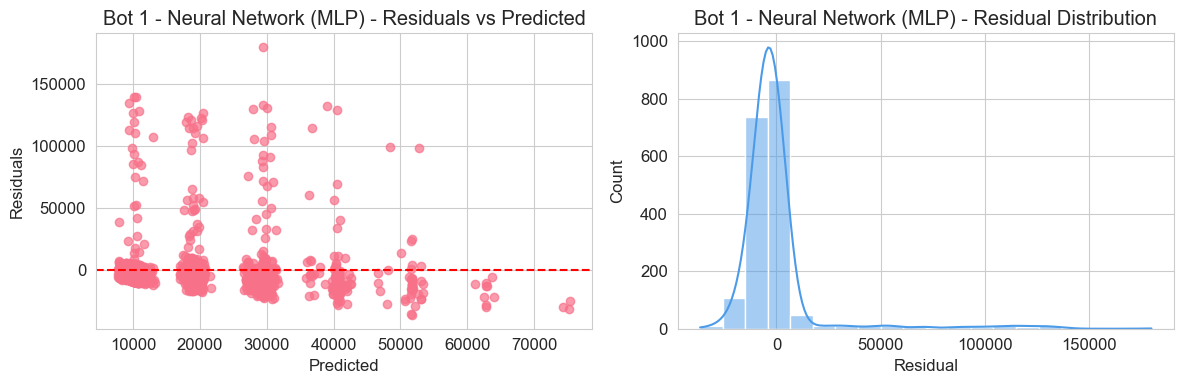

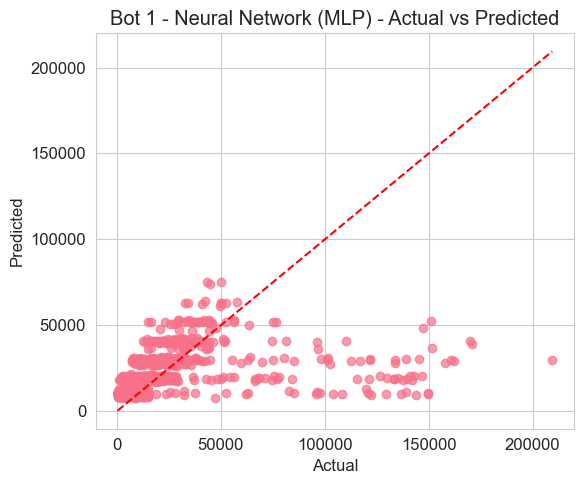

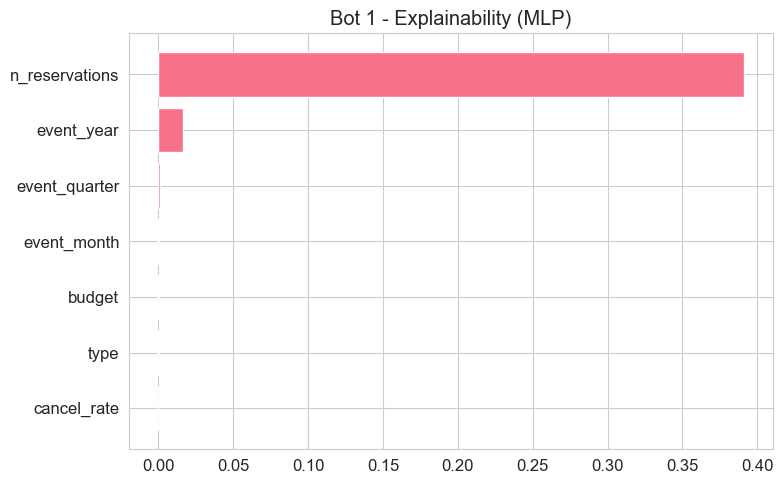

Bot 1 - Assumption checks (LSTM branch):
{'residual_mean': -285.4370995046018, 'residual_std': 20760.344033854675, 'shapiro_p': 3.717057144120158e-58, 'spearman_absres_pred_p': 5.543493899615047e-54}


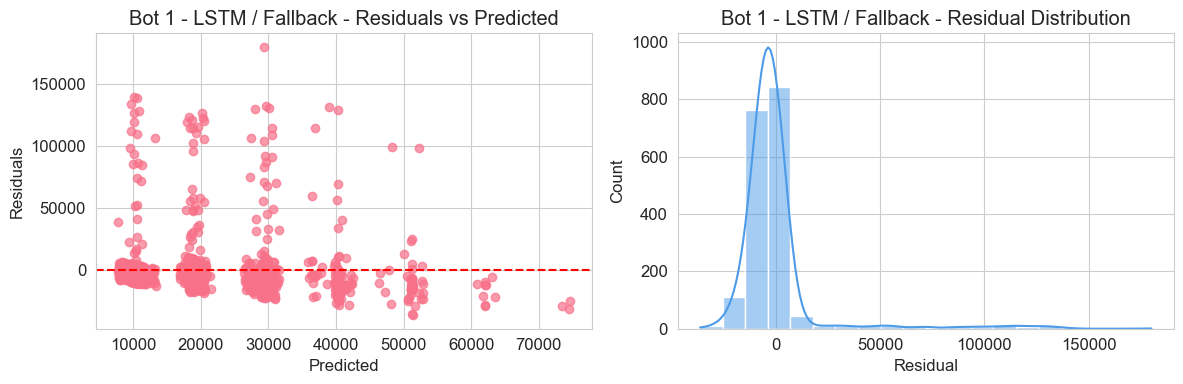

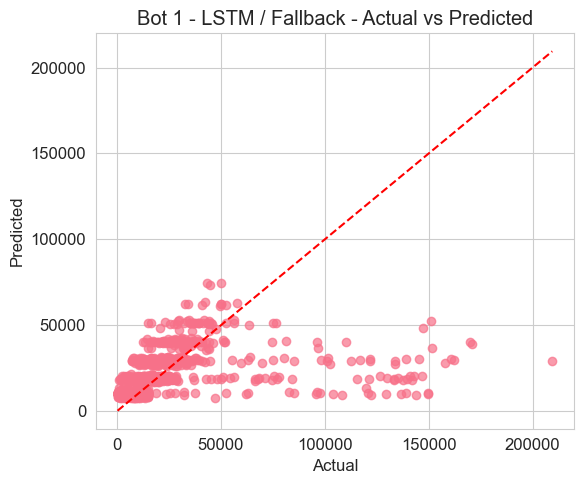

In [68]:
# ==========================================================
# BOT 1 - Predict Revenue (CA) / Forecast financial performance
# Models: Neural Network (MLP) vs LSTM (or fallback)
# ==========================================================

res_b1 = reservation.copy()
evt_b1 = event.copy()

if 'event_date' in evt_b1.columns:
    evt_b1['event_date'] = pd.to_datetime(evt_b1['event_date'], errors='coerce')
else:
    evt_b1['event_date'] = pd.NaT

if 'status' in res_b1.columns:
    res_b1['is_cancelled'] = res_b1['status'].astype(str).str.lower().isin(['cancelled', 'canceled', 'annule', 'annulé']).astype(int)
else:
    res_b1['is_cancelled'] = 0

event_rev = (
    res_b1.groupby('id_event').agg(
        event_revenue=('final_price', 'sum'),
        n_reservations=('id_reservation', 'nunique'),
        cancel_rate=('is_cancelled', 'mean')
    ).reset_index()
)

bot1_df = evt_b1[[c for c in ['id_event', 'budget', 'type', 'event_date'] if c in evt_b1.columns]].merge(
    event_rev, on='id_event', how='inner'
)
bot1_df = bot1_df[bot1_df['event_revenue'].notna()].copy()

bot1_df['event_year'] = bot1_df['event_date'].dt.year.fillna(0)
bot1_df['event_month'] = bot1_df['event_date'].dt.month.fillna(0)
bot1_df['event_quarter'] = bot1_df['event_date'].dt.quarter.fillna(0)

num_cols1 = [c for c in ['budget', 'n_reservations', 'cancel_rate', 'event_year', 'event_month', 'event_quarter'] if c in bot1_df.columns]
cat_cols1 = [c for c in ['type'] if c in bot1_df.columns]

X1 = bot1_df[num_cols1 + cat_cols1].copy()
y1 = bot1_df['event_revenue'].copy()

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=RANDOM_STATE_REG
)
cv1 = make_cv(len(X1_train))

preprocess1 = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols1),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols1),
    ],
    remainder='drop'
)

mlp_pipe_1 = Pipeline([
    ('preprocess', preprocess1),
    ('model', MLPRegressor(random_state=RANDOM_STATE_REG, max_iter=1200))
])

grid_mlp_1 = GridSearchCV(
    estimator=mlp_pipe_1,
    param_grid={
        'model__hidden_layer_sizes': [(64, 32), (128, 64)],
        'model__alpha': [1e-4, 1e-3, 1e-2],
        'model__learning_rate_init': [1e-3, 1e-2],
    },
    scoring='neg_root_mean_squared_error',
    cv=cv1,
    n_jobs=-1
)
grid_mlp_1.fit(X1_train, y1_train)

best_mlp_1 = grid_mlp_1.best_estimator_
yhat_mlp_1 = best_mlp_1.predict(X1_test)
m_mlp_1 = regression_metrics(y1_test, yhat_mlp_1)
m_mlp_1.update({
    'model': 'Neural Network (MLP)',
    'cv_rmse_mean': -grid_mlp_1.best_score_,
    'cv_rmse_std': np.nan,
})

# LSTM branch (time-series monthly revenue)
monthly_rev = evt_b1[['id_event', 'event_date']].merge(event_rev[['id_event', 'event_revenue']], on='id_event', how='inner').copy()
monthly_rev = monthly_rev[monthly_rev['event_date'].notna()].copy()
monthly_rev['month_key'] = monthly_rev['event_date'].dt.to_period('M').dt.to_timestamp()
monthly_series = monthly_rev.groupby('month_key')['event_revenue'].sum().sort_index()

def build_sequences(series_values, window=3):
    X_seq, y_seq = [], []
    for i in range(window, len(series_values)):
        X_seq.append(series_values[i-window:i])
        y_seq.append(series_values[i])
    return np.array(X_seq), np.array(y_seq)

lstm_result = None
lstm_model_obj = None
yhat_lstm_test = None
y_lstm_test = None

try:
    import tensorflow as tf
    tf.random.set_seed(RANDOM_STATE_REG)
    has_tf = True
except Exception:
    has_tf = False

if has_tf and len(monthly_series) >= 12:
    from sklearn.preprocessing import MinMaxScaler

    window = 3
    vals = monthly_series.values.reshape(-1, 1).astype(float)
    scaler_lstm = MinMaxScaler()
    vals_scaled = scaler_lstm.fit_transform(vals).flatten()

    X_seq, y_seq = build_sequences(vals_scaled, window=window)
    if len(X_seq) >= 8:
        split_idx = int(len(X_seq) * 0.8)
        X_seq_train, X_seq_test = X_seq[:split_idx], X_seq[split_idx:]
        y_seq_train, y_seq_test = y_seq[:split_idx], y_seq[split_idx:]

        X_seq_train = X_seq_train.reshape((X_seq_train.shape[0], X_seq_train.shape[1], 1))
        X_seq_test = X_seq_test.reshape((X_seq_test.shape[0], X_seq_test.shape[1], 1))

        lstm_model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(window, 1)),
            tf.keras.layers.LSTM(32),
            tf.keras.layers.Dense(16, activation='relu'),
            tf.keras.layers.Dense(1),
        ])
        lstm_model.compile(optimizer='adam', loss='mse')

        cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
        lstm_model.fit(
            X_seq_train, y_seq_train,
            validation_split=0.2,
            epochs=150,
            batch_size=8,
            verbose=0,
            callbacks=[cb],
        )

        yhat_seq_scaled = lstm_model.predict(X_seq_test, verbose=0).flatten()
        yhat_lstm_test = scaler_lstm.inverse_transform(yhat_seq_scaled.reshape(-1, 1)).flatten()
        y_lstm_test = scaler_lstm.inverse_transform(y_seq_test.reshape(-1, 1)).flatten()

        m_lstm = regression_metrics(y_lstm_test, yhat_lstm_test)
        m_lstm.update({
            'model': 'LSTM',
            'cv_rmse_mean': np.nan,
            'cv_rmse_std': np.nan,
        })
        lstm_result = m_lstm
        lstm_model_obj = {'model': lstm_model, 'scaler': scaler_lstm, 'window': window}
    else:
        print('⚠️ LSTM non entraine: serie temporelle trop courte apres fenetrage.')

if lstm_result is None:
    # Fallback model if TensorFlow/LSTM not available or not enough sequence length
    mlp_fallback_1 = Pipeline([
        ('preprocess', preprocess1),
        ('model', MLPRegressor(hidden_layer_sizes=(32, 16), alpha=1e-3, random_state=RANDOM_STATE_REG, max_iter=1200))
    ])
    m_fb_1, best_fb_1, yhat_fb_1 = evaluate_regression_model(
        'LSTM fallback (MLP-small)', mlp_fallback_1, X1_train, y1_train, X1_test, y1_test, cv=cv1
    )
    lstm_result = m_fb_1
    lstm_model_obj = best_fb_1
    yhat_lstm_test = yhat_fb_1
    y_lstm_test = y1_test

bot1_results = pd.DataFrame([m_mlp_1, lstm_result]).sort_values(['rmse', 'mae'])
print('📊 Bot 1 - Model comparison')
display(bot1_results)

print('Bot 1 - Assumption checks (MLP):')
print(assumption_check(y1_test, yhat_mlp_1))
plot_residuals(y1_test, yhat_mlp_1, 'Bot 1 - Neural Network (MLP)')
plot_actual_vs_pred(y1_test, yhat_mlp_1, 'Bot 1 - Neural Network (MLP)')
plot_explainability(best_mlp_1, X1_test, y1_test, 'Bot 1 - Explainability (MLP)')

print('Bot 1 - Assumption checks (LSTM branch):')
print(assumption_check(y_lstm_test, yhat_lstm_test))
plot_residuals(y_lstm_test, yhat_lstm_test, 'Bot 1 - LSTM / Fallback')
plot_actual_vs_pred(y_lstm_test, yhat_lstm_test, 'Bot 1 - LSTM / Fallback')

📊 Bot 2 - Model comparison


,mse,rmse,mae,r2,model,cv_rmse_mean,cv_rmse_std
0,0.006036,0.077692,0.047445,0.842307,Random Forest,0.109437,NaN
1,0.006909,0.083119,0.050334,0.819509,XGBoost,0.111238,NaN


Bot 2 - Assumption checks (Random Forest):
{'residual_mean': -0.003074931084884817, 'residual_std': 0.07763135916812035, 'shapiro_p': 6.825247647034514e-08, 'spearman_absres_pred_p': 1.1435284356553378e-05}


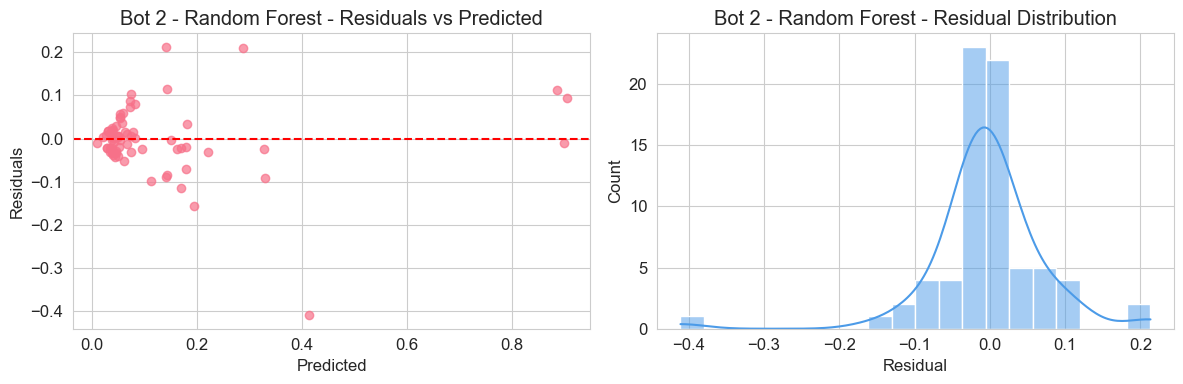

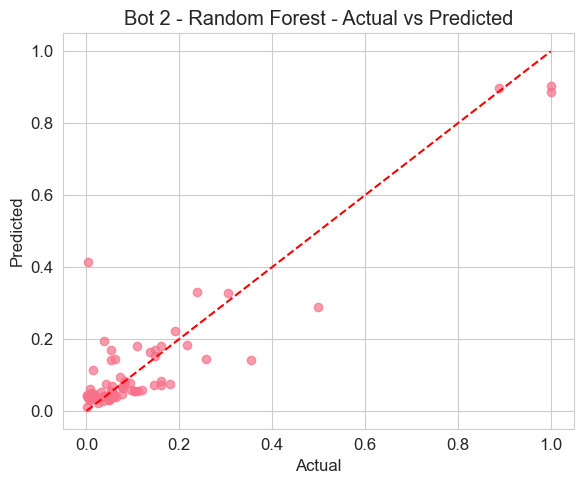

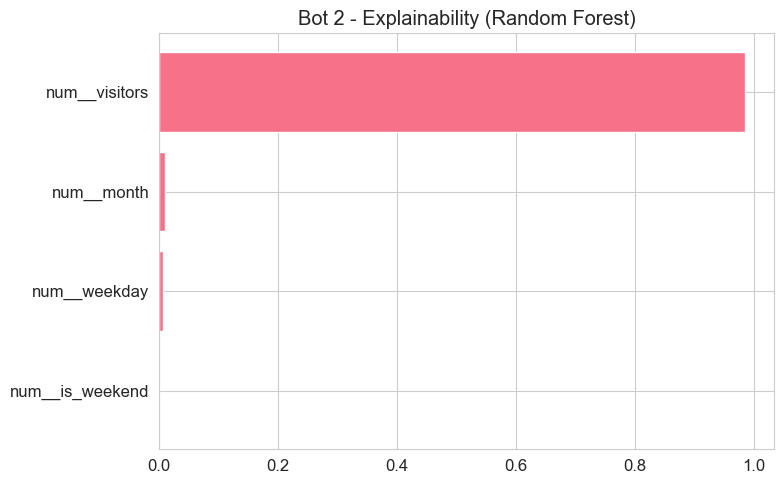

Bot 2 - Assumption checks (XGBoost/Fallback):
{'residual_mean': -0.003589684328757266, 'residual_std': 0.08304127756879769, 'shapiro_p': 2.112137566515672e-08, 'spearman_absres_pred_p': 0.0002693780973093891}


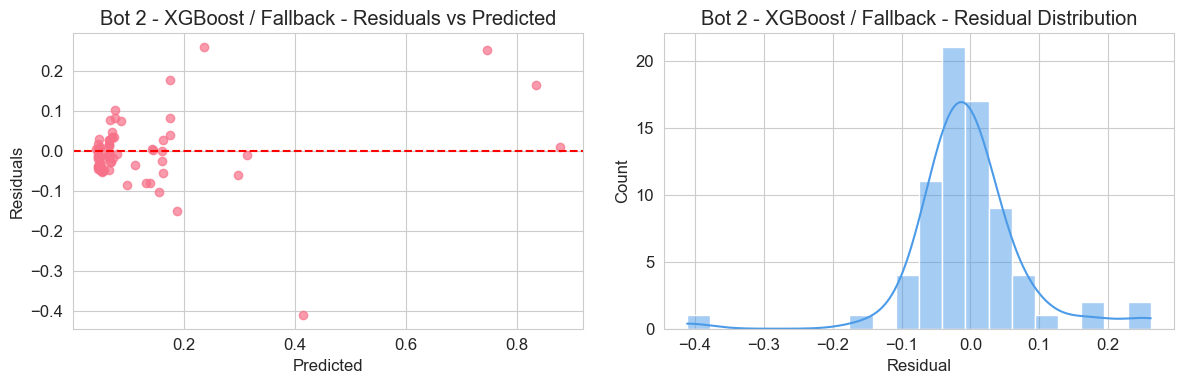

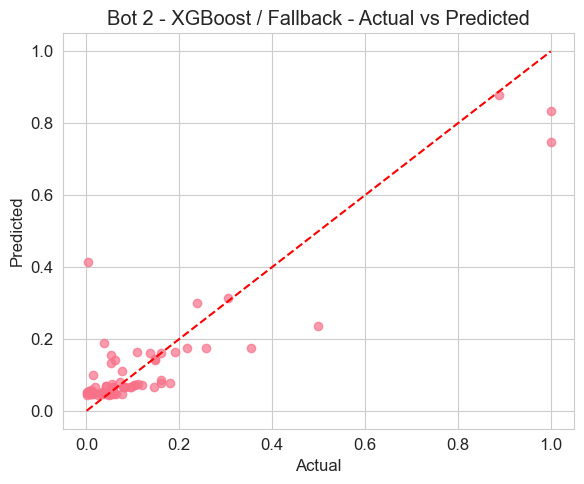

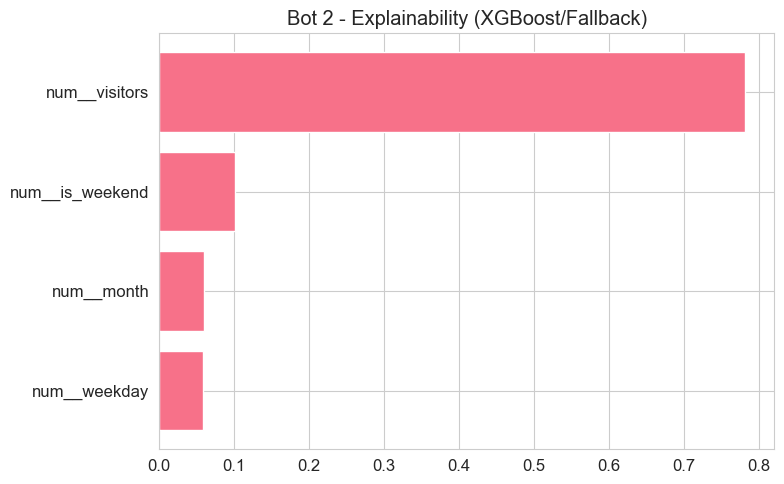

In [69]:
# ==========================================================
# BOT 2 - Predict Conversion Rate / Optimize marketing campaigns
# Models: Random Forest vs XGBoost (or fallback)
# ==========================================================

vis_b2 = visitors.copy()
mkt_b2 = marketing.copy()

def _normalize_month_series(s):
    # Try numeric months first
    s_num = pd.to_numeric(s, errors='coerce')
    if s_num.notna().any():
        return s_num

    # Try month names (full then short)
    s_str = s.astype(str).str.strip()
    s_full = pd.to_datetime(s_str, format='%B', errors='coerce').dt.month
    s_short = pd.to_datetime(s_str, format='%b', errors='coerce').dt.month
    return s_full.fillna(s_short)

# Visitors side: derive month robustly
if 'date' in vis_b2.columns:
    vis_b2['date'] = pd.to_datetime(vis_b2['date'], errors='coerce')
    vis_b2['month_num'] = vis_b2['date'].dt.month
    vis_b2['weekday'] = vis_b2['date'].dt.weekday
elif 'month' in vis_b2.columns:
    vis_b2['month_num'] = _normalize_month_series(vis_b2['month'])
    vis_b2['weekday'] = np.arange(len(vis_b2)) % 7
else:
    vis_b2['month_num'] = (np.arange(len(vis_b2)) % 12) + 1
    vis_b2['weekday'] = np.arange(len(vis_b2)) % 7

# Conversion rate target
vis_b2['visitors'] = pd.to_numeric(vis_b2['visitors'], errors='coerce')
vis_b2['reservations'] = pd.to_numeric(vis_b2['reservations'], errors='coerce')
vis_b2['conversion_rate'] = (
    vis_b2['reservations'].astype(float) / vis_b2['visitors'].replace(0, np.nan).astype(float)
)
vis_b2['conversion_rate'] = vis_b2['conversion_rate'].replace([np.inf, -np.inf], np.nan).clip(0, 1)

# Marketing side: derive month robustly
if 'date' in mkt_b2.columns:
    mkt_b2['date'] = pd.to_datetime(mkt_b2['date'], errors='coerce')
    mkt_b2['month_num'] = mkt_b2['date'].dt.month
elif 'month' in mkt_b2.columns:
    mkt_b2['month_num'] = _normalize_month_series(mkt_b2['month'])
else:
    mkt_b2['month_num'] = (np.arange(len(mkt_b2)) % 12) + 1

mkt_b2['marketing_spend'] = pd.to_numeric(mkt_b2['marketing_spend'], errors='coerce')
mkt_month = mkt_b2.groupby('month_num', as_index=False)['marketing_spend'].mean()

# Safe merge on numeric month key
vis_b2['month_num'] = pd.to_numeric(vis_b2['month_num'], errors='coerce')
mkt_month['month_num'] = pd.to_numeric(mkt_month['month_num'], errors='coerce')
bot2_df = vis_b2.merge(mkt_month, on='month_num', how='left')
bot2_df['month'] = bot2_df['month_num']
bot2_df['is_weekend'] = bot2_df['weekday'].isin([5, 6]).astype(int)

num_cols2 = [c for c in ['visitors', 'marketing_spend', 'month', 'weekday', 'is_weekend'] if c in bot2_df.columns]
X2 = bot2_df[num_cols2].copy()
y2 = bot2_df['conversion_rate'].copy()

mask2 = y2.notna()
X2 = X2[mask2]
y2 = y2[mask2]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE_REG
)
cv2 = make_cv(len(X2_train))

preprocess2 = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols2),
    ],
    remainder='drop'
)

rf_pipe_2 = Pipeline([
    ('preprocess', preprocess2),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE_REG, n_jobs=-1))
])

grid_rf_2 = RandomizedSearchCV(
    estimator=rf_pipe_2,
    param_distributions={
        'model__n_estimators': [200, 300, 500],
        'model__max_depth': [None, 6, 10, 14],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
    },
    n_iter=12,
    scoring='neg_root_mean_squared_error',
    cv=cv2,
    random_state=RANDOM_STATE_REG,
    n_jobs=-1
)
grid_rf_2.fit(X2_train, y2_train)
best_rf_2 = grid_rf_2.best_estimator_
yhat_rf_2 = best_rf_2.predict(X2_test)
m_rf_2 = regression_metrics(y2_test, yhat_rf_2)
m_rf_2.update({
    'model': 'Random Forest',
    'cv_rmse_mean': -grid_rf_2.best_score_,
    'cv_rmse_std': np.nan,
})

xgb_ok = True
try:
    from xgboost import XGBRegressor
except Exception:
    xgb_ok = False

if xgb_ok:
    xgb_pipe_2 = Pipeline([
        ('preprocess', preprocess2),
        ('model', XGBRegressor(
            objective='reg:squarederror',
            random_state=RANDOM_STATE_REG,
            n_jobs=-1
        ))
    ])

    grid_xgb_2 = RandomizedSearchCV(
        estimator=xgb_pipe_2,
        param_distributions={
            'model__n_estimators': [200, 300, 500],
            'model__max_depth': [2, 3, 4, 6],
            'model__learning_rate': [0.02, 0.05, 0.1],
            'model__subsample': [0.7, 0.85, 1.0],
            'model__colsample_bytree': [0.7, 0.85, 1.0],
        },
        n_iter=12,
        scoring='neg_root_mean_squared_error',
        cv=cv2,
        random_state=RANDOM_STATE_REG,
        n_jobs=-1
    )
    grid_xgb_2.fit(X2_train, y2_train)
    best_xgb_2 = grid_xgb_2.best_estimator_
    yhat_xgb_2 = best_xgb_2.predict(X2_test)
    m_xgb_2 = regression_metrics(y2_test, yhat_xgb_2)
    m_xgb_2.update({
        'model': 'XGBoost',
        'cv_rmse_mean': -grid_xgb_2.best_score_,
        'cv_rmse_std': np.nan,
    })
else:
    gb_pipe_2 = Pipeline([
        ('preprocess', preprocess2),
        ('model', GradientBoostingRegressor(random_state=RANDOM_STATE_REG))
    ])
    m_xgb_2, best_xgb_2, yhat_xgb_2 = evaluate_regression_model(
        'XGBoost fallback (GradientBoosting)', gb_pipe_2, X2_train, y2_train, X2_test, y2_test, cv=cv2
    )

bot2_results = pd.DataFrame([m_rf_2, m_xgb_2]).sort_values(['rmse', 'mae'])
print('📊 Bot 2 - Model comparison')
display(bot2_results)

print('Bot 2 - Assumption checks (Random Forest):')
print(assumption_check(y2_test, yhat_rf_2))
plot_residuals(y2_test, yhat_rf_2, 'Bot 2 - Random Forest')
plot_actual_vs_pred(y2_test, yhat_rf_2, 'Bot 2 - Random Forest')
plot_explainability(best_rf_2, X2_test, y2_test, 'Bot 2 - Explainability (Random Forest)')

print('Bot 2 - Assumption checks (XGBoost/Fallback):')
print(assumption_check(y2_test, yhat_xgb_2))
plot_residuals(y2_test, yhat_xgb_2, 'Bot 2 - XGBoost / Fallback')
plot_actual_vs_pred(y2_test, yhat_xgb_2, 'Bot 2 - XGBoost / Fallback')
plot_explainability(best_xgb_2, X2_test, y2_test, 'Bot 2 - Explainability (XGBoost/Fallback)')

📊 Bot 3 - Model comparison


,mse,rmse,mae,r2,model,cv_rmse_mean,cv_rmse_std
1,2.790202e-07,0.000528,0.000416,0.999959,SVR,0.004067,NaN
0,2.255943e-06,0.001502,0.001163,0.999666,Lasso,0.004828,NaN


Bot 3 - Assumption checks (Lasso):
{'residual_mean': 0.0002623638159010298, 'residual_std': 0.0014788875252035073, 'shapiro_p': 0.000539922261848865, 'spearman_absres_pred_p': 0.003234603349099278}


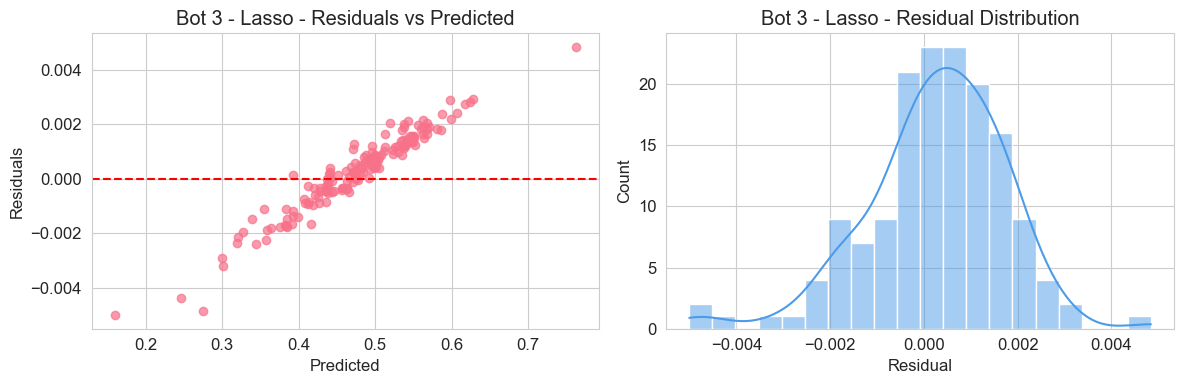

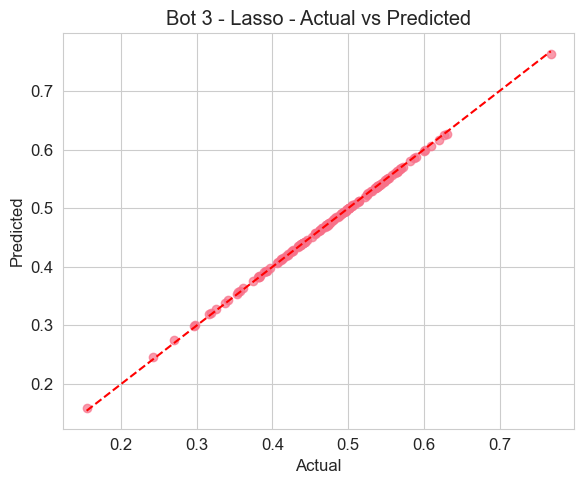

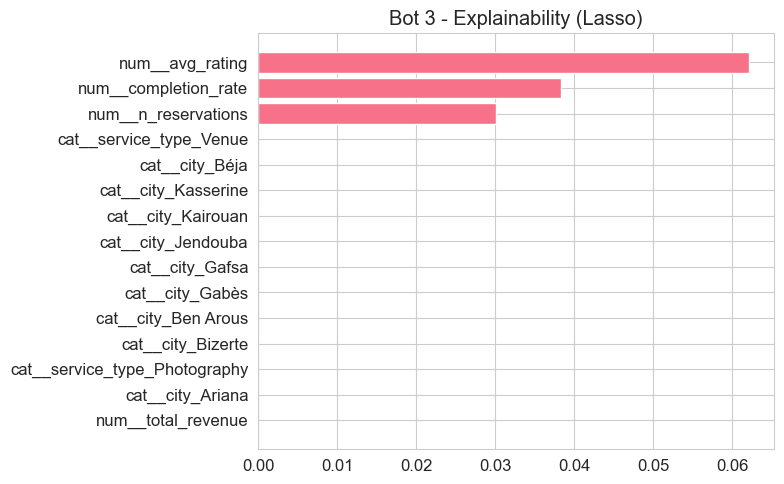

Bot 3 - Assumption checks (SVR):
{'residual_mean': -7.184666672165568e-05, 'residual_std': 0.0005233146620191493, 'shapiro_p': 0.9933433014217925, 'spearman_absres_pred_p': 0.621251581497384}


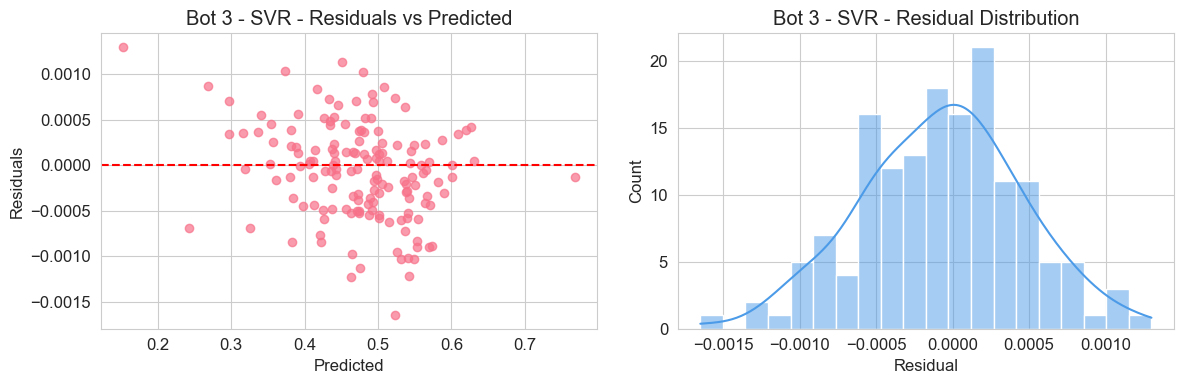

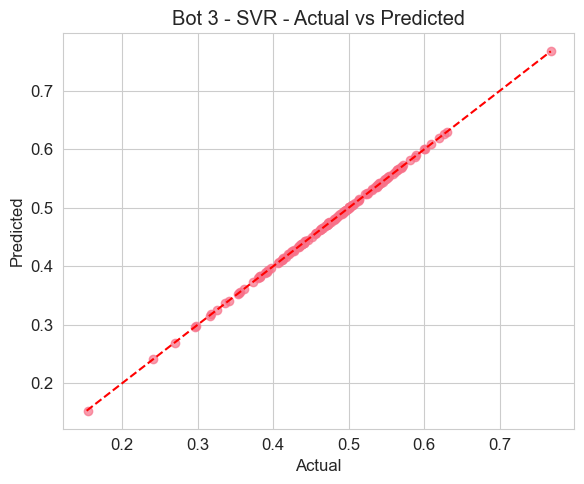

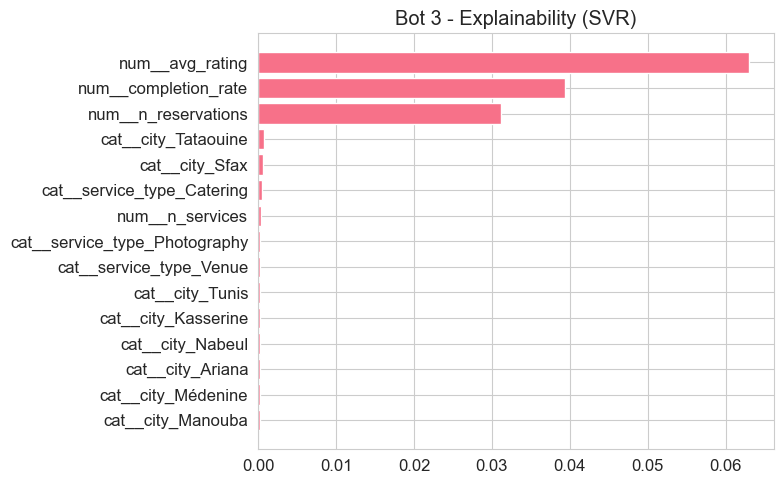

Top Lasso coefficients (Bot 3):


,feature,coef
6,num__avg_rating,0.062162
5,num__completion_rate,0.038294
1,num__n_reservations,0.030143
27,cat__city_Tataouine,-0.000000
21,cat__city_Médenine,0.000000
22,cat__city_Nabeul,0.000000
23,cat__city_Sfax,0.000000
24,cat__city_Sidi Bouzid,0.000000
25,cat__city_Siliana,0.000000
26,cat__city_Sousse,0.000000


In [70]:
# ==========================================================
# BOT 3 - Provider Performance Scoring
# Models: Lasso vs SVR
# ==========================================================

svc_b3 = service[[c for c in ['id_service', 'id_provider', 'price'] if c in service.columns]].copy()
res_b3 = reservation[[c for c in ['id_reservation', 'id_service', 'final_price', 'status'] if c in reservation.columns]].copy()
evl_b3 = evaluation[[c for c in ['id_reservation', 'rating'] if c in evaluation.columns]].copy()
prv_b3 = provider[[c for c in ['id_provider', 'city', 'service_type'] if c in provider.columns]].copy()

if 'status' in res_b3.columns:
    res_b3['is_completed'] = (~res_b3['status'].astype(str).str.lower().isin(['cancelled', 'canceled', 'annule', 'annulé'])).astype(int)
else:
    res_b3['is_completed'] = 1

prov_raw = svc_b3.merge(res_b3, on='id_service', how='left').merge(evl_b3, on='id_reservation', how='left')

prov_agg = prov_raw.groupby('id_provider').agg(
    n_services=('id_service', 'nunique'),
    n_reservations=('id_reservation', 'nunique'),
    avg_service_price=('price', 'mean'),
    avg_final_price=('final_price', 'mean'),
    total_revenue=('final_price', 'sum'),
    completion_rate=('is_completed', 'mean'),
    avg_rating=('rating', 'mean'),
).reset_index()

prov_agg = prov_agg.merge(prv_b3, on='id_provider', how='left')
prov_agg['avg_rating'] = prov_agg['avg_rating'].fillna(prov_agg['avg_rating'].median())

def minmax_series(s):
    s = s.astype(float)
    d = s.max() - s.min()
    if d == 0 or np.isnan(d):
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / d

rating_norm = minmax_series(prov_agg['avg_rating'])
volume_norm = minmax_series(prov_agg['n_reservations'])
completion_norm = prov_agg['completion_rate'].fillna(0).clip(0, 1)

prov_agg['provider_score'] = 0.5 * rating_norm + 0.3 * completion_norm + 0.2 * volume_norm

num_cols3 = [c for c in ['n_services', 'n_reservations', 'avg_service_price', 'avg_final_price', 'total_revenue', 'completion_rate', 'avg_rating'] if c in prov_agg.columns]
cat_cols3 = [c for c in ['city', 'service_type'] if c in prov_agg.columns]

X3 = prov_agg[num_cols3 + cat_cols3].copy()
y3 = prov_agg['provider_score'].copy()

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=RANDOM_STATE_REG
)
cv3 = make_cv(len(X3_train))

preprocess3 = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols3),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols3),
    ],
    remainder='drop'
)

lasso_pipe_3 = Pipeline([
    ('preprocess', preprocess3),
    ('model', Lasso(random_state=RANDOM_STATE_REG, max_iter=5000))
])

grid_lasso_3 = GridSearchCV(
    estimator=lasso_pipe_3,
    param_grid={'model__alpha': [1e-4, 1e-3, 1e-2, 1e-1, 1.0]},
    scoring='neg_root_mean_squared_error',
    cv=cv3,
    n_jobs=-1
)
grid_lasso_3.fit(X3_train, y3_train)
best_lasso_3 = grid_lasso_3.best_estimator_
yhat_lasso_3 = best_lasso_3.predict(X3_test)
m_lasso_3 = regression_metrics(y3_test, yhat_lasso_3)
m_lasso_3.update({
    'model': 'Lasso',
    'cv_rmse_mean': -grid_lasso_3.best_score_,
    'cv_rmse_std': np.nan,
})

svr_pipe_3 = Pipeline([
    ('preprocess', preprocess3),
    ('model', SVR())
])

grid_svr_3 = RandomizedSearchCV(
    estimator=svr_pipe_3,
    param_distributions={
        'model__C': [0.5, 1.0, 3.0, 10.0, 30.0],
        'model__epsilon': [0.001, 0.01, 0.05, 0.1],
        'model__gamma': ['scale', 'auto'],
        'model__kernel': ['rbf', 'linear'],
    },
    n_iter=12,
    scoring='neg_root_mean_squared_error',
    cv=cv3,
    random_state=RANDOM_STATE_REG,
    n_jobs=-1
)
grid_svr_3.fit(X3_train, y3_train)
best_svr_3 = grid_svr_3.best_estimator_
yhat_svr_3 = best_svr_3.predict(X3_test)
m_svr_3 = regression_metrics(y3_test, yhat_svr_3)
m_svr_3.update({
    'model': 'SVR',
    'cv_rmse_mean': -grid_svr_3.best_score_,
    'cv_rmse_std': np.nan,
})

bot3_results = pd.DataFrame([m_lasso_3, m_svr_3]).sort_values(['rmse', 'mae'])
print('📊 Bot 3 - Model comparison')
display(bot3_results)

print('Bot 3 - Assumption checks (Lasso):')
print(assumption_check(y3_test, yhat_lasso_3))
plot_residuals(y3_test, yhat_lasso_3, 'Bot 3 - Lasso')
plot_actual_vs_pred(y3_test, yhat_lasso_3, 'Bot 3 - Lasso')
plot_explainability(best_lasso_3, X3_test, y3_test, 'Bot 3 - Explainability (Lasso)')

print('Bot 3 - Assumption checks (SVR):')
print(assumption_check(y3_test, yhat_svr_3))
plot_residuals(y3_test, yhat_svr_3, 'Bot 3 - SVR')
plot_actual_vs_pred(y3_test, yhat_svr_3, 'Bot 3 - SVR')
plot_explainability(best_svr_3, X3_test, y3_test, 'Bot 3 - Explainability (SVR)')

# Extra interpretation: Lasso coefficients
feat_names_lasso = best_lasso_3.named_steps['preprocess'].get_feature_names_out()
coef_lasso = best_lasso_3.named_steps['model'].coef_
coef_df_lasso = pd.DataFrame({'feature': feat_names_lasso, 'coef': coef_lasso})
coef_df_lasso['abs_coef'] = coef_df_lasso['coef'].abs()
coef_df_lasso = coef_df_lasso.sort_values('abs_coef', ascending=False)

print('Top Lasso coefficients (Bot 3):')
display(coef_df_lasso.head(15)[['feature', 'coef']])

In [71]:
# ==========================================================
# Resume global + export des meilleurs modeles par bot
# ==========================================================

bot1_best = bot1_results.sort_values(['rmse', 'mae', 'r2'], ascending=[True, True, False]).iloc[0].to_dict()
bot2_best = bot2_results.sort_values(['rmse', 'mae', 'r2'], ascending=[True, True, False]).iloc[0].to_dict()
bot3_best = bot3_results.sort_values(['rmse', 'mae', 'r2'], ascending=[True, True, False]).iloc[0].to_dict()

summary_reg = pd.DataFrame([
    {'bot': 'Bot 1 - Revenue Forecast', **bot1_best},
    {'bot': 'Bot 2 - Conversion Rate', **bot2_best},
    {'bot': 'Bot 3 - Provider Scoring', **bot3_best},
])

print('🏆 Best model per regression bot')
display(summary_reg[['bot', 'model', 'mse', 'rmse', 'mae', 'r2', 'cv_rmse_mean']])

# Selection des objets modeles gagnants
if bot1_best['model'] == 'Neural Network (MLP)':
    best_model_bot1_reg = best_mlp_1
else:
    best_model_bot1_reg = lstm_model_obj

best_model_bot2_reg = best_rf_2 if bot2_best['model'] == 'Random Forest' else best_xgb_2
best_model_bot3_reg = best_lasso_3 if bot3_best['model'] == 'Lasso' else best_svr_3

# Dossier models (cherche le plus proche en remontant)
models_dir = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / 'models').exists():
        models_dir = p / 'models'
        break
if models_dir is None:
    models_dir = Path.cwd() / 'models'
    models_dir.mkdir(parents=True, exist_ok=True)

import pickle

bot1_reg_path = models_dir / 'bot1_revenue_regressor.pkl'
bot2_reg_path = models_dir / 'bot2_conversion_regressor.pkl'
bot3_reg_path = models_dir / 'bot3_provider_scoring_regressor.pkl'

# Bot 1: cas special si vrai LSTM TensorFlow
if isinstance(best_model_bot1_reg, dict) and 'model' in best_model_bot1_reg and hasattr(best_model_bot1_reg['model'], 'save'):
    bot1_lstm_path = models_dir / 'bot1_revenue_lstm.keras'
    best_model_bot1_reg['model'].save(bot1_lstm_path)

    bot1_meta_path = models_dir / 'bot1_revenue_lstm_metadata.pkl'
    bot1_meta = {
        'window': best_model_bot1_reg.get('window', 3),
        'scaler': best_model_bot1_reg.get('scaler', None),
        'model_path': str(bot1_lstm_path),
    }
    with open(bot1_meta_path, 'wb') as f:
        pickle.dump(bot1_meta, f)
else:
    with open(bot1_reg_path, 'wb') as f:
        pickle.dump(best_model_bot1_reg, f)

with open(bot2_reg_path, 'wb') as f:
    pickle.dump(best_model_bot2_reg, f)
with open(bot3_reg_path, 'wb') as f:
    pickle.dump(best_model_bot3_reg, f)

print('💾 Modeles regression sauvegardes separement:')
if isinstance(best_model_bot1_reg, dict) and 'model' in best_model_bot1_reg and hasattr(best_model_bot1_reg['model'], 'save'):
    print(f'- Bot 1 (LSTM model): {models_dir / "bot1_revenue_lstm.keras"}')
    print(f'- Bot 1 (LSTM metadata): {models_dir / "bot1_revenue_lstm_metadata.pkl"}')
else:
    print(f'- Bot 1: {bot1_reg_path}')
print(f'- Bot 2: {bot2_reg_path}')
print(f'- Bot 3: {bot3_reg_path}')

🏆 Best model per regression bot


,bot,model,mse,rmse,mae,r2,cv_rmse_mean
0,Bot 1 - Revenue Forecast,LSTM fallback (MLP-small),4.310734e+08,20762.306200,9636.371651,0.165886,21169.982126
1,Bot 2 - Conversion Rate,Random Forest,6.036083e-03,0.077692,0.047445,0.842307,0.109437
2,Bot 3 - Provider Scoring,SVR,2.790202e-07,0.000528,0.000416,0.999959,0.004067


💾 Modeles regression sauvegardes separement:
- Bot 1: c:\Users\chari\.gemini\antigravity\scratch\EventZella\notebooks\models\bot1_revenue_regressor.pkl
- Bot 2: c:\Users\chari\.gemini\antigravity\scratch\EventZella\notebooks\models\bot2_conversion_regressor.pkl
- Bot 3: c:\Users\chari\.gemini\antigravity\scratch\EventZella\notebooks\models\bot3_provider_scoring_regressor.pkl
